#TASK 1: DATA LOADING & INITIAL EXPLORATION  

In [35]:
import pandas as pd
df = pd.read_csv('customer_churn_messi.csv')
print('Shape of Dataset:',df.shape)
print('\ncolumns:\n', df.columns.tolist())
print('\nFirst 10 rows:\n')
print(df.head(10))
print('\nLast 10 Rows\n')
print(df.tail(10))
print('\nSummary:\n')
print(df.describe(include ='all'))
print('\nCount Of missing values:\n')
print(df.isnull().sum())
print('\nPercentage of missing values:\n')
percentage = (df.isnull().sum() / len(df)) * 100
print(percentage.sort_values(ascending = False))
duplicate = df.duplicated().sum()
print('Total duplicate rows: ',duplicate)
print()
print(df.dtypes)

Shape of Dataset: (15000, 21)

columns:
 ['CustomerID', 'Gender', 'Age', 'Tenure_Months', 'MonthlyCharges', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PhoneService', 'NumSupportTickets', 'CustomerSatisfactionScore', 'TotalCharges', 'MultipleLines', 'Churn']

First 10 rows:

  CustomerID  Gender  Age  Tenure_Months  MonthlyCharges        Contract  \
0     C00001    Male   69             18           57.36  Month-to-month   
1     C00002  Female   21             58           65.73        Two year   
2     C00003    Male   51             32           47.90  Month-to-month   
3     C00004    Male   22             49           90.80  Month-to-month   
4     C00005    Male   50             48           39.17  Month-to-month   
5     C00006  Female   74             71          126.27        One year   
6     C00007    Male   22             65           49.33  Month-

#TASK 2: DATA CLEANING

TotalCharges    50
dtype: int64
TotalCharges    0.333333
dtype: float64


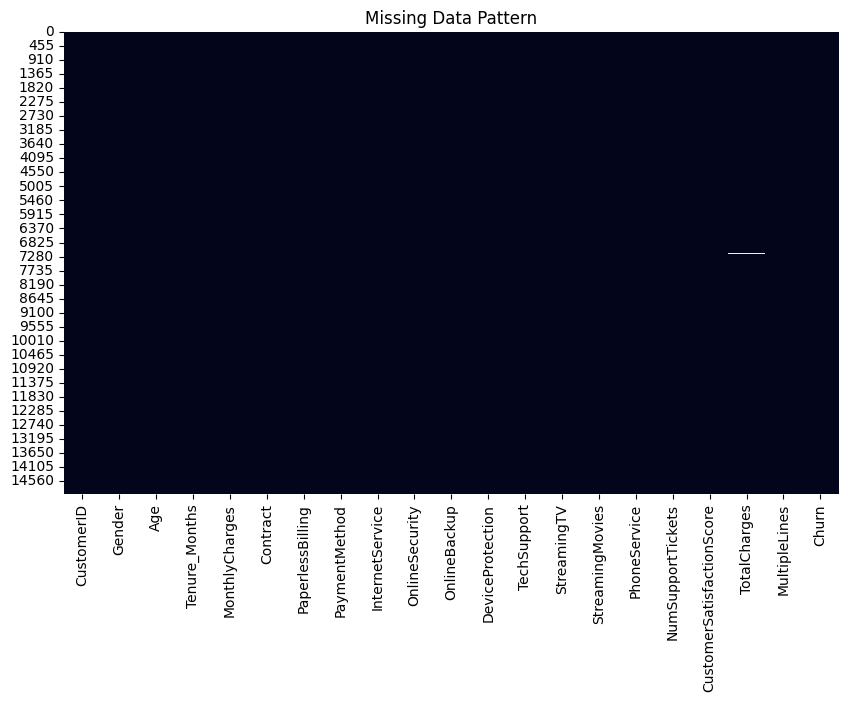

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)


plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()


DECISION:
The data is highly consistante. There is few missing value the data set out of 15000 records. Percentage of the missing value is 0.333. The percentage is too minor that why this is better to fill the missing value with mean rather than drop. 

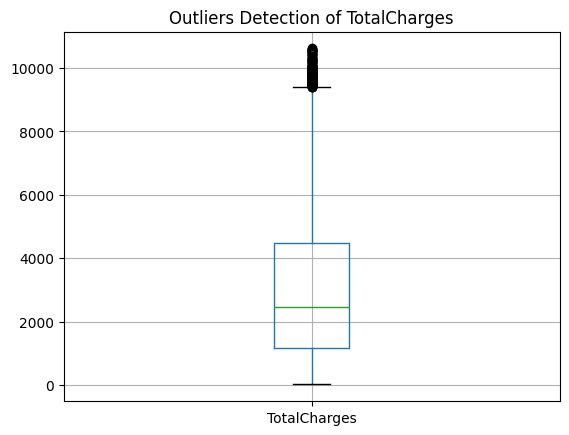

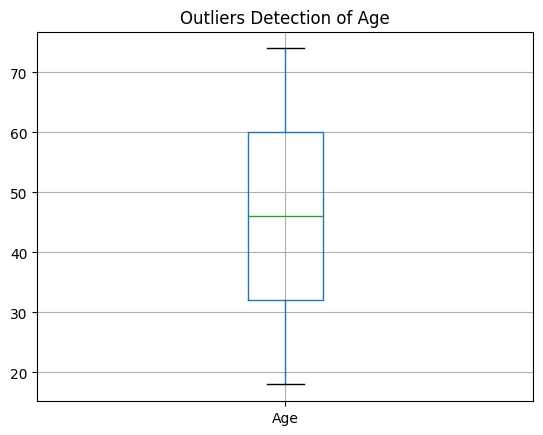

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
df.boxplot(column =['TotalCharges'])
plt.title('Outliers Detection of TotalCharges')
plt.show()
df.boxplot(column =['Age'])
plt.title('Outliers Detection of Age')
plt.show()



In [39]:
Q1 = df[['Age', 'TotalCharges','Tenure_Months','MonthlyCharges','NumSupportTickets','CustomerSatisfactionScore', 'Churn']].quantile(.25)
Q3 = df[['Age', 'TotalCharges','Tenure_Months','MonthlyCharges','NumSupportTickets','CustomerSatisfactionScore', 'Churn' ]].quantile(.75)
IQR = Q3 - Q1
Lower = Q1 - 1.5*IQR
Upper = Q3 + 1.5*IQR
df = df[
    ~((df[["Age","TotalCharges",'Tenure_Months','MonthlyCharges','NumSupportTickets','CustomerSatisfactionScore', 'Churn']] < Lower) |
      (df[["Age","TotalCharges",'Tenure_Months','MonthlyCharges','NumSupportTickets','CustomerSatisfactionScore', 'Churn']] > Upper)).any(axis=1)
]
df['ChargePerMonth'] = df['TotalCharges'] / df['Tenure_Months']
df['ChargePerMonth'] = df['ChargePerMonth'].round(2)
df['TotalCharges'] = df['TotalCharges'].round(2)

bins = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49-72']
df['TenureGroup'] = pd.cut(df['Tenure_Months'], bins=bins, labels=labels)
services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (df[services] == "Yes").sum(axis=1)
df_encoded = pd.get_dummies(df, drop_first=True)
df.drop("CustomerID", axis=1, inplace=True)


for i in df.columns:
    df[i] = df[i].replace("No internet service", "No")
df.to_csv("cleaned_data.csv", index=False)


#TASK 3: EXPLORATORY DATA ANALYSIS (EDA)

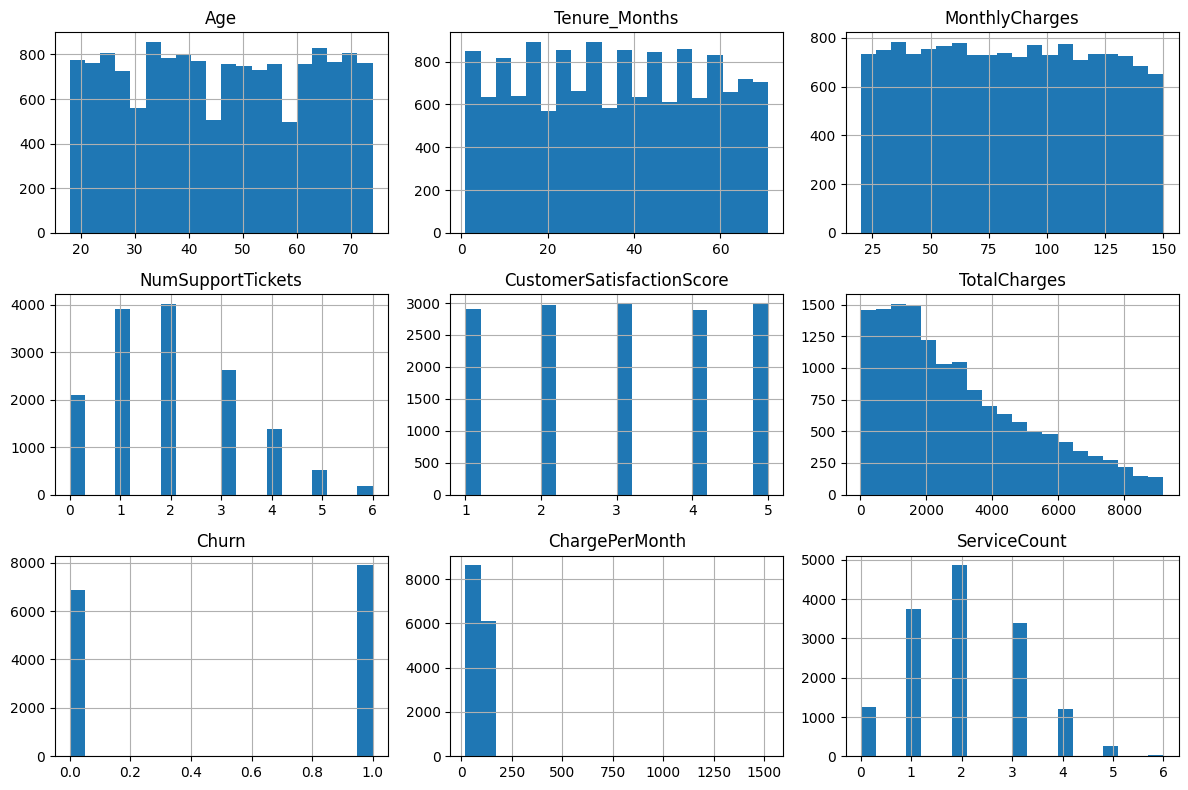

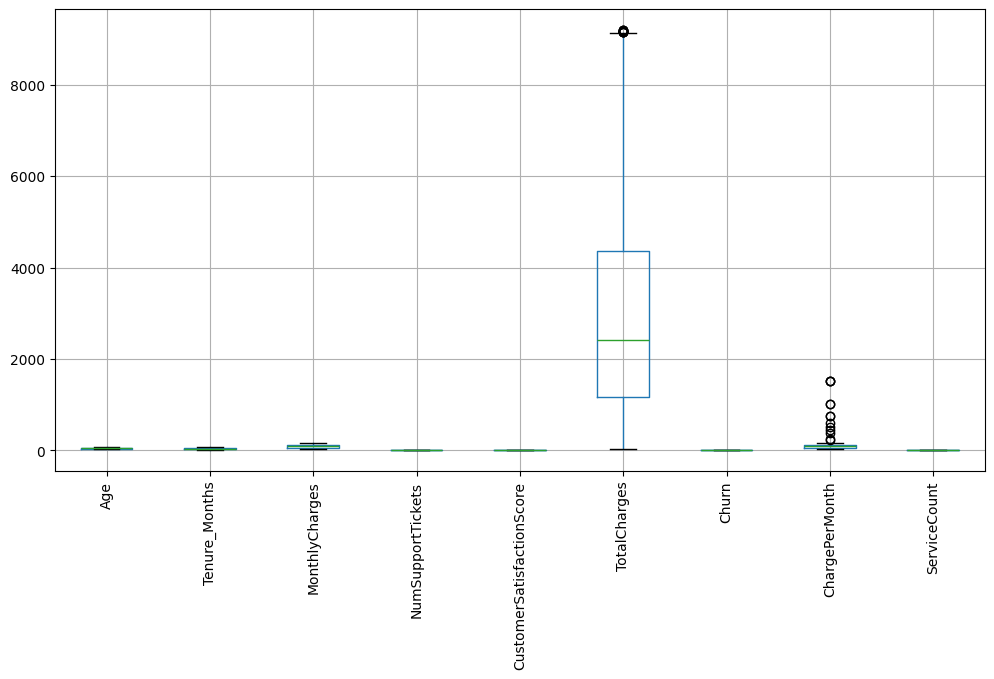

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df1 = pd.read_csv('cleaned_data.csv')
num_cols = df1.select_dtypes(include=["int64","float64"]).columns
import matplotlib.pyplot as plt

df1[num_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,6))
df1[num_cols].boxplot()
plt.xticks(rotation=90)
plt.show()



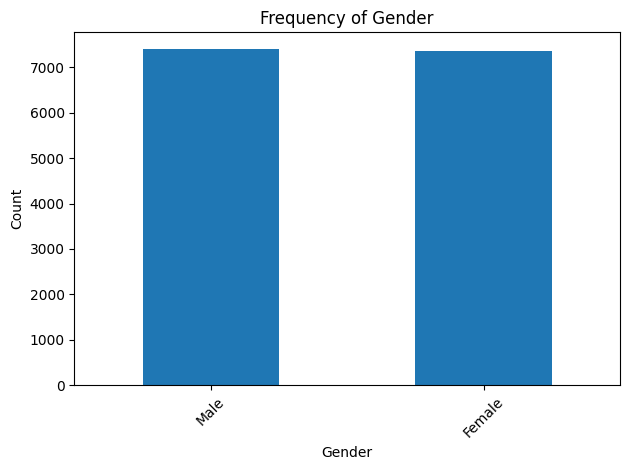

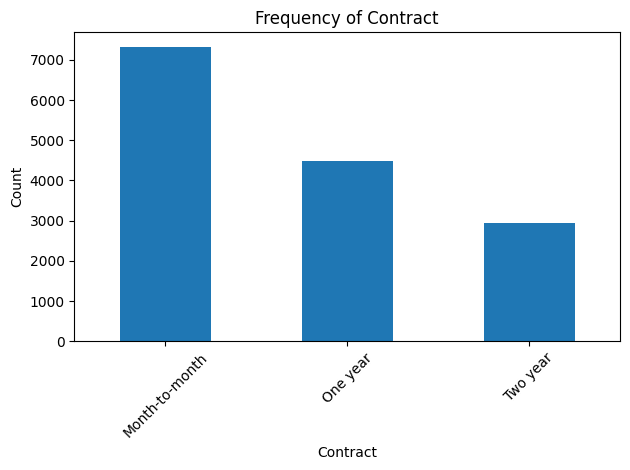

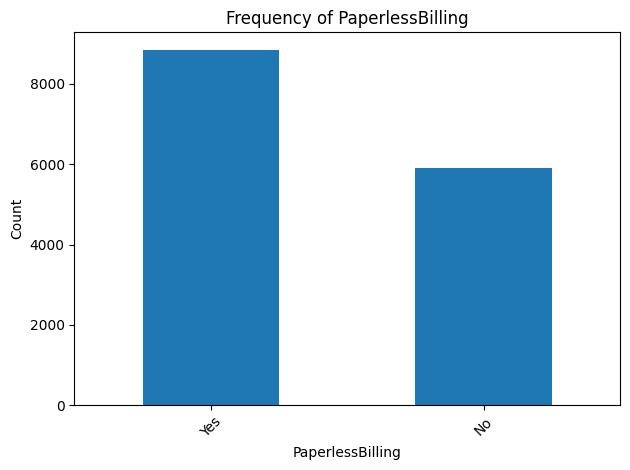

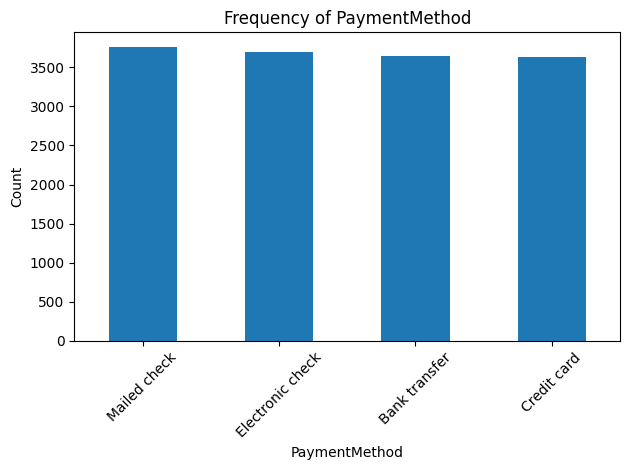

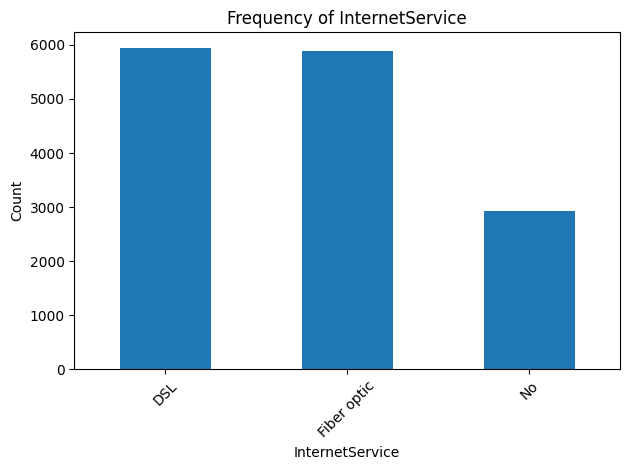

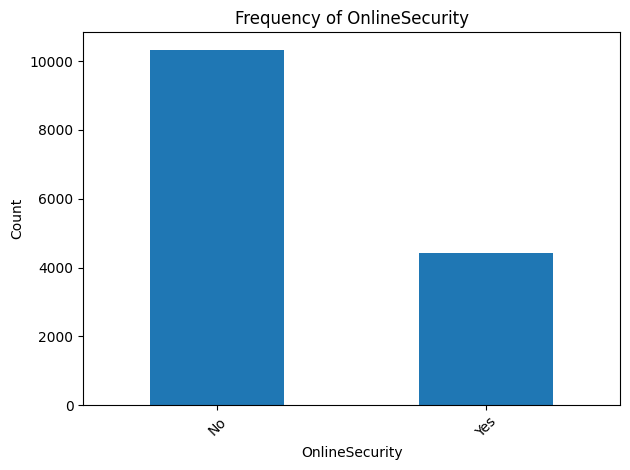

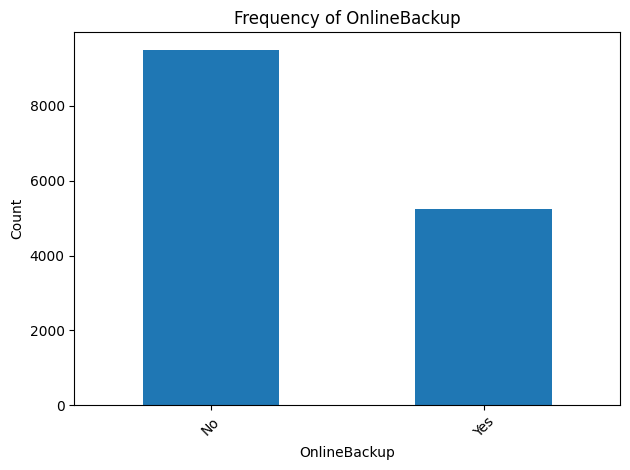

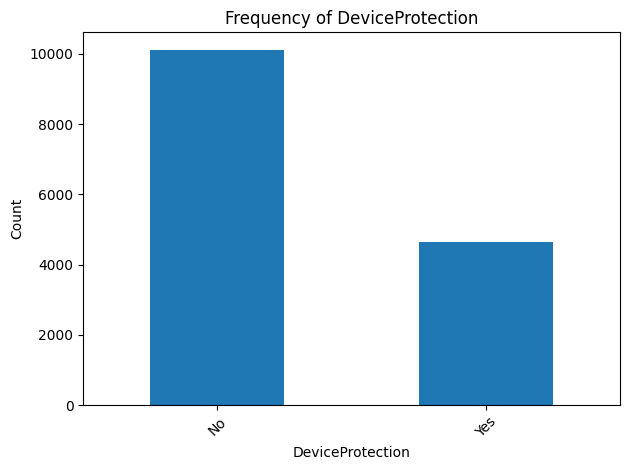

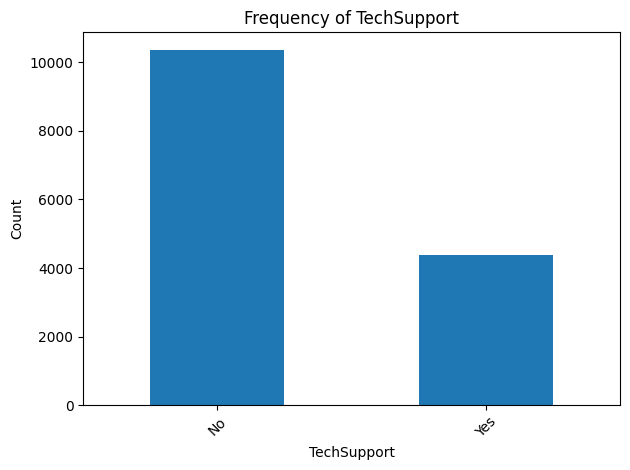

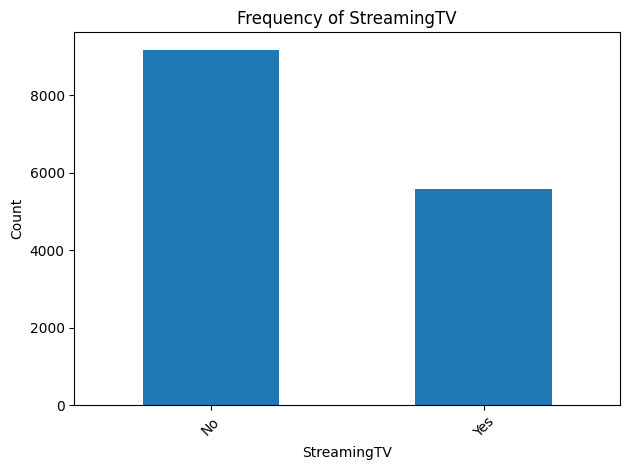

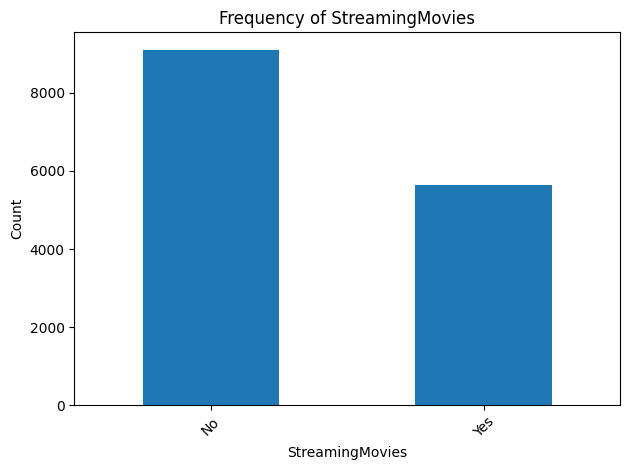

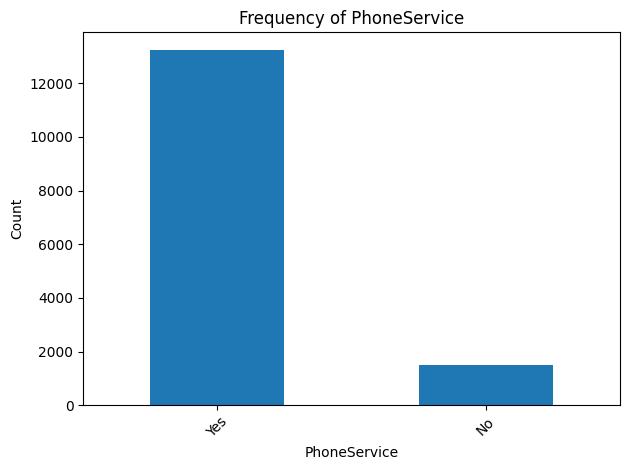

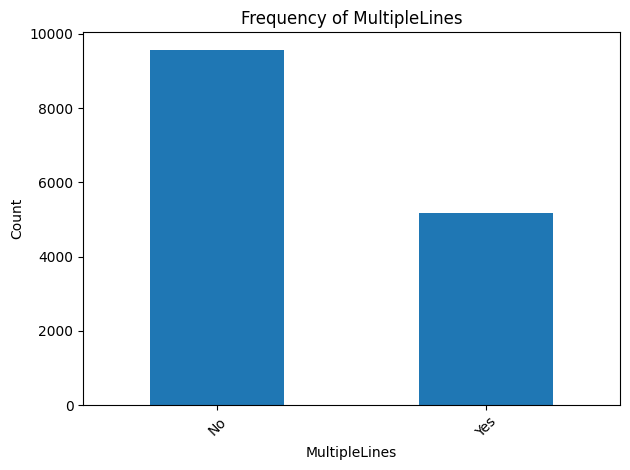

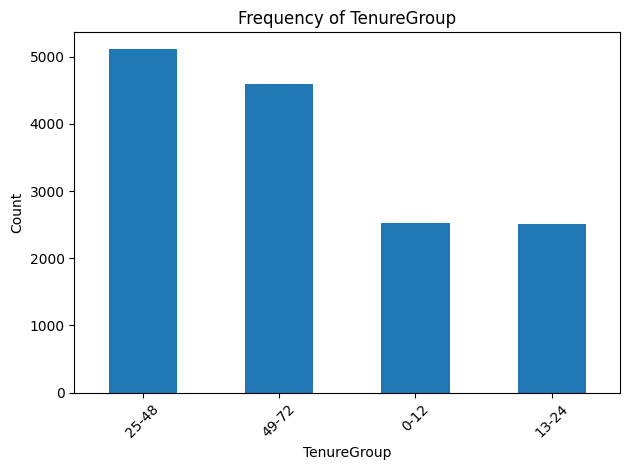

In [5]:
import matplotlib.pyplot as plt
cat_cols = df1.select_dtypes(include="object").columns
for col in cat_cols:
    plt.figure()
    df1[col].value_counts().plot(kind="bar")
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



In [9]:
churn_rate = (df1['Churn'].mean()*100).round(2)
print("Overall Churn Rate:", churn_rate, "%")

Overall Churn Rate: 53.54 %


In [10]:
cat_column = df1.select_dtypes(include='object').columns
for i in cat_column:
    print((df1.groupby(i)['Churn'].mean()*100).round(2))

Gender
Female    53.55
Male      53.53
Name: Churn, dtype: float64
Contract
Month-to-month    77.54
One year          29.69
Two year          30.18
Name: Churn, dtype: float64
PaperlessBilling
No     53.45
Yes    53.60
Name: Churn, dtype: float64
PaymentMethod
Bank transfer       51.51
Credit card         51.00
Electronic check    60.21
Mailed check        51.41
Name: Churn, dtype: float64
InternetService
DSL            53.21
Fiber optic    53.59
No             54.10
Name: Churn, dtype: float64
OnlineSecurity
No     55.51
Yes    48.93
Name: Churn, dtype: float64
OnlineBackup
No     53.20
Yes    54.15
Name: Churn, dtype: float64
DeviceProtection
No     53.18
Yes    54.32
Name: Churn, dtype: float64
TechSupport
No     53.92
Yes    52.63
Name: Churn, dtype: float64
StreamingTV
No     53.36
Yes    53.83
Name: Churn, dtype: float64
StreamingMovies
No     53.52
Yes    53.57
Name: Churn, dtype: float64
PhoneService
No     51.23
Yes    53.80
Name: Churn, dtype: float64
MultipleLines
No     53.

In [60]:
cat_column = df1.select_dtypes(include=["int64","float64"]).columns
correlaton_with_chure = df1[cat_column].corr()['Churn'].sort_values()
print(correlaton_with_chure)

CustomerSatisfactionScore   -0.168307
Tenure_Months               -0.123801
ServiceCount                -0.018453
TotalCharges                -0.003151
Age                          0.006387
NumSupportTickets            0.061168
ChargePerMonth               0.128463
MonthlyCharges               0.145335
Churn                        1.000000
Name: Churn, dtype: float64


In [11]:


demo_cols = ['Age',"Gender", "TenureGroup"]
for i in demo_cols:
    print((df1.groupby(i)['Churn'].mean()*100).round(2))
    

Age
18    47.51
19    56.22
20    53.41
21    50.00
22    46.72
23    52.21
24    57.72
25    50.55
26    53.23
27    48.77
28    52.91
29    47.44
30    55.36
31    54.21
32    58.31
33    58.80
34    52.38
35    51.33
36    53.93
37    54.96
38    55.13
39    54.69
40    54.48
41    53.36
42    51.24
43    56.49
44    53.60
45    55.51
46    52.33
47    59.91
48    56.39
49    62.45
50    58.82
51    52.73
52    52.21
53    56.78
54    51.97
55    47.86
56    50.81
57    55.69
58    51.79
59    49.80
60    50.65
61    51.30
62    58.37
63    49.59
64    51.11
65    53.33
66    55.31
67    52.26
68    50.37
69    57.25
70    53.18
71    60.59
72    53.09
73    50.00
74    54.12
Name: Churn, dtype: float64
Gender
Female    53.55
Male      53.53
Name: Churn, dtype: float64
TenureGroup
0-12     73.10
13-24    49.86
25-48    49.44
49-72    49.36
Name: Churn, dtype: float64


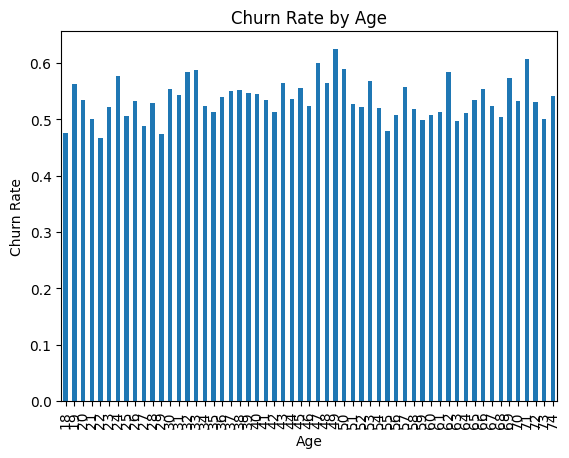

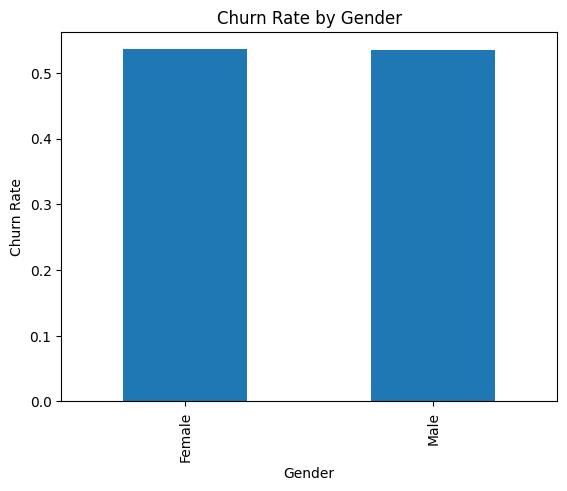

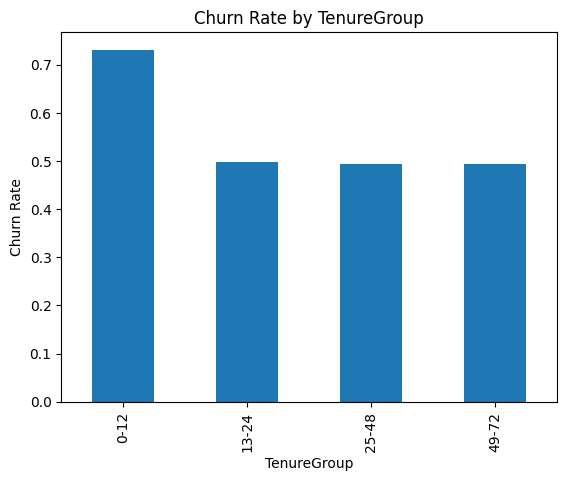

In [12]:
import matplotlib.pyplot as plt

for col in demo_cols:
    df1.groupby(col)["Churn"].mean().plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.show()


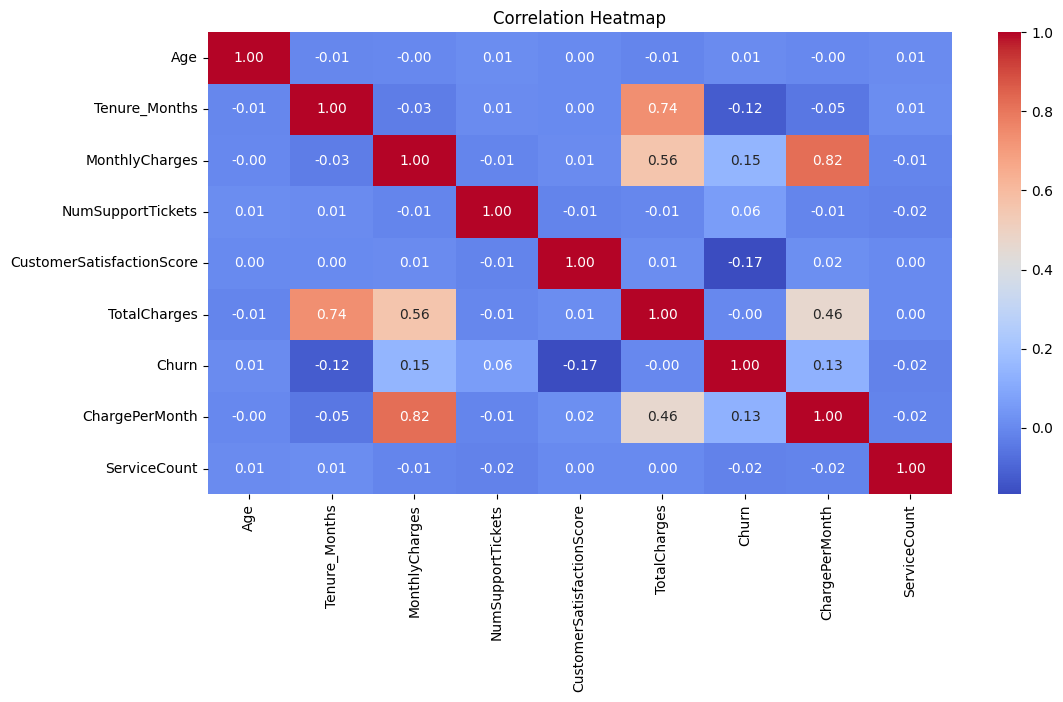

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# select numeric columns only
num_df = df1.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(12,6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



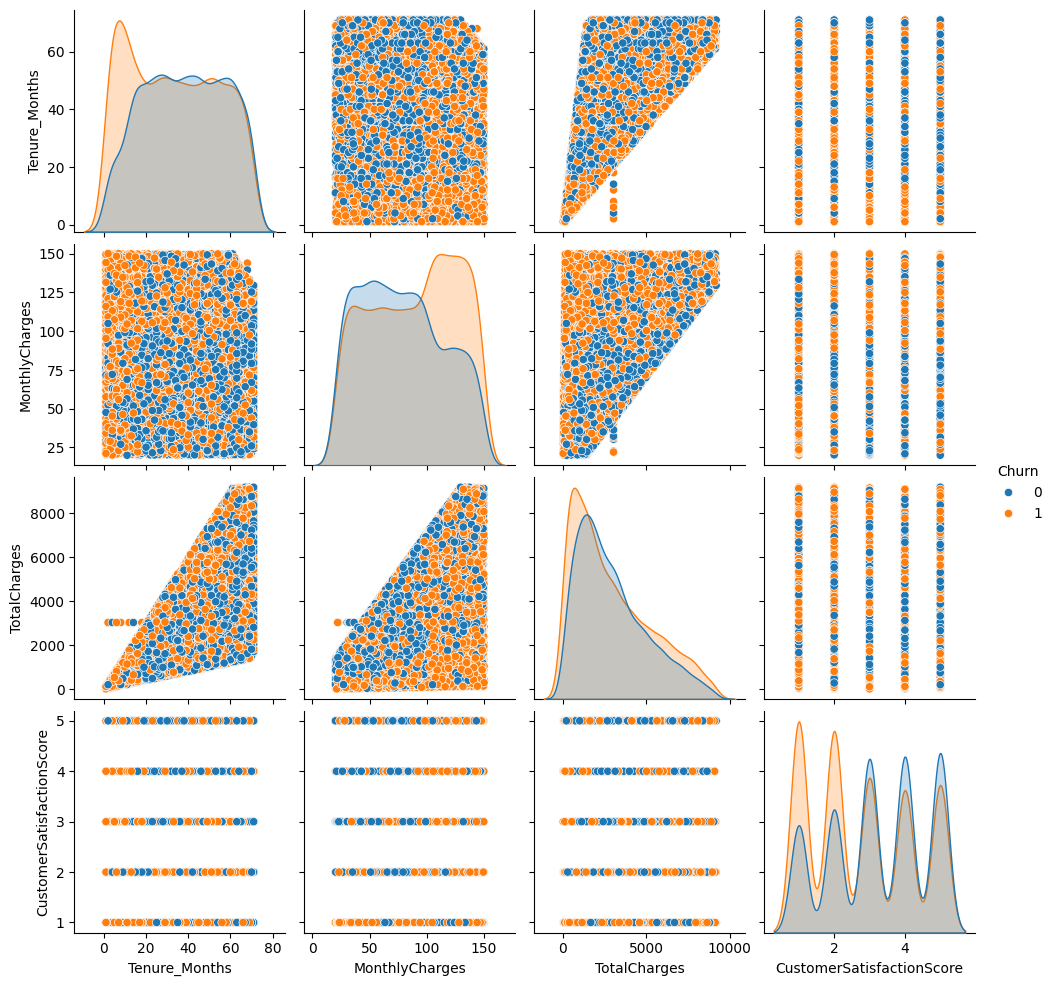

In [14]:
features = [
    "Tenure_Months",
    "MonthlyCharges",
    "TotalCharges",
    "CustomerSatisfactionScore",
    "Churn"
]
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df1[features], hue="Churn")
plt.show()


In [13]:
features = [
    "Tenure_Months",
    "MonthlyCharges",
    "TotalCharges",
    "CustomerSatisfactionScore",
    "Churn"
]
analysis = df1.groupby(["Tenure_Months","MonthlyCharges","TotalCharges","CustomerSatisfactionScore","Churn"])["Churn"].mean()*100
print(analysis)


Tenure_Months  MonthlyCharges  TotalCharges  CustomerSatisfactionScore  Churn
1              20.46           20.46         3                          1        100.0
               21.17           21.17         3                          1        100.0
               21.56           21.56         4                          1        100.0
               22.58           22.58         3                          1        100.0
               23.09           23.09         3                          0          0.0
                                                                                 ...  
71             124.14          8813.94       5                          1        100.0
               124.94          8870.74       5                          0          0.0
               126.27          8965.17       3                          0          0.0
               127.45          9048.95       2                          1        100.0
               129.46          9191.66       5      

<function matplotlib.pyplot.show(close=None, block=None)>

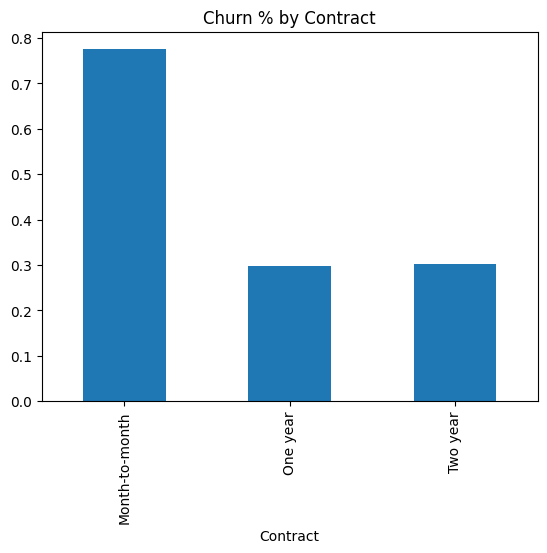

In [5]:
import matplotlib.pyplot as plt
df1.groupby('Contract')['Churn'].mean().round(2).sort_values(ascending = False)
df1.groupby('Contract')['Churn'].mean().plot(kind='bar')
plt.title('Churn % by Contract')
plt.show

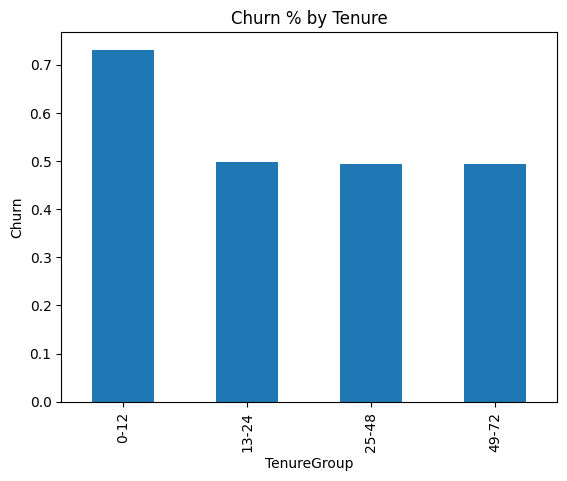

In [15]:
import matplotlib.pyplot as plt
df1.groupby('TenureGroup')['Churn'].mean().round(2).sort_values(ascending = False)
df1.groupby('TenureGroup')['Churn'].mean().plot(kind = 'bar')
plt.title('Churn % by Tenure')
plt.ylabel('Churn')
plt.show()

C:\Users\PIJUSH PANDIT\AppData\Local\Temp\ipykernel_14320\3349684253.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('ChargeGroup')['Churn'].mean().plot(kind = 'bar')


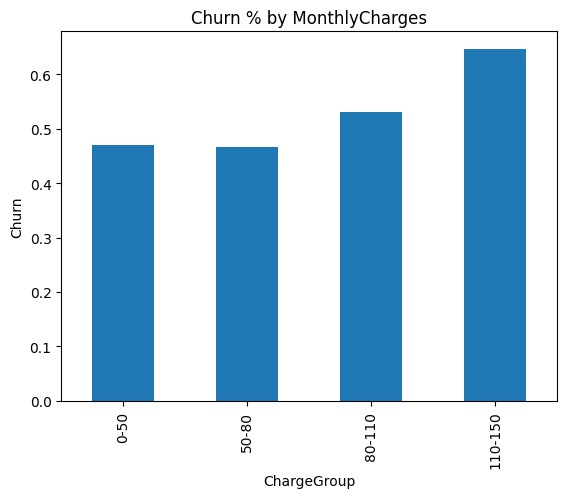

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
bins = [0, 50, 80, 110, 150]
labels = ["0-50", "50-80", "80-110", "110-150"]
df1["ChargeGroup"] = pd.cut(df1["MonthlyCharges"], bins=bins, labels=labels)
df1.groupby('MonthlyCharges')['Churn'].mean().round(2).sort_values(ascending = False)
df1.groupby('ChargeGroup')['Churn'].mean().plot(kind = 'bar')
plt.title('Churn % by MonthlyCharges')
plt.ylabel('Churn')
plt.show()

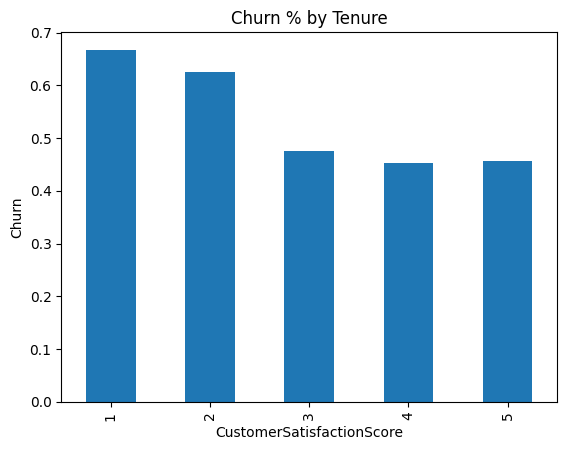

In [33]:
import matplotlib.pyplot as plt
df1.groupby('CustomerSatisfactionScore')['Churn'].mean().round(2).sort_values(ascending = False)
df1.groupby('CustomerSatisfactionScore')['Churn'].mean().plot(kind = 'bar')
plt.title('Churn % by Tenure')
plt.ylabel('Churn')
plt.show()

TASK 4: FEATURE ENGINEERING

In [29]:
Tenure_MonthlyCharges= df1["Tenure_MonthlyCharges"] = df1["Tenure_Months"] * df1["MonthlyCharges"]
print(Tenure_MonthlyCharges)

0        1032.48
1        3812.34
2        1532.80
3        4449.20
4        1880.16
          ...   
14740    2341.80
14741    3134.44
14742    2418.15
14743    5329.73
14744    4131.54
Length: 14745, dtype: float64


In [28]:
Service_Satisfaction_Interaction = service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PhoneService",
    "MultipleLines"
]

df1["ServiceCount"] = df1[service_cols].apply(lambda row: sum(row=="Yes"), axis=1)
df1["Service_Satisfaction_Interaction"] = (
    df1["ServiceCount"] * df1["CustomerSatisfactionScore"]
)
print(Service_Satisfaction_Interaction)

['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PhoneService', 'MultipleLines']


In [20]:
Contract_TenureGroup = df1["Contract_TenureGroup"] = (
    df1["Contract"] + "_" + df1["TenureGroup"].astype(str)
)
print(Contract_TenureGroup)

0        Month-to-month_13-24
1              Two year_49-72
2        Month-to-month_25-48
3        Month-to-month_49-72
4        Month-to-month_25-48
                 ...         
14740          Two year_25-48
14741          Two year_25-48
14742          Two year_25-48
14743    Month-to-month_49-72
14744    Month-to-month_25-48
Length: 14745, dtype: object


In [21]:
AvgChargePerService = df1["AvgChargePerService"] = df1["MonthlyCharges"] / df1["ServiceCount"]
print(AvgChargePerService)


0        19.120000
1        13.146000
2        15.966667
3        22.700000
4         9.792500
           ...    
14740    17.346667
14741    13.628000
14742    25.725000
14743    36.256667
14744    19.674000
Length: 14745, dtype: float64


In [22]:
ServiceAdoptionRate= df1["ServiceAdoptionRate"] = df1["ServiceCount"] / len(service_cols)
print(ServiceAdoptionRate)

0        0.375
1        0.625
2        0.375
3        0.500
4        0.500
         ...  
14740    0.375
14741    0.625
14742    0.250
14743    0.375
14744    0.625
Name: ServiceCount, Length: 14745, dtype: float64


In [23]:
df1["IsLongTermContract"] = (df1["Contract"] != "Month-to-month").astype(int)


In [24]:
df1["HasMultipleServices"] = (df1["ServiceCount"] > 1).astype(int)


In [26]:
threshold = df1["TotalCharges"].quantile(0.75)
df1["IsHighValue"] = (df1["TotalCharges"] >= threshold).astype(int)


In [27]:
df1["IsAtRisk"] = (
    (df1["CustomerSatisfactionScore"] <= 2) &
    (df1["NumSupportTickets"] >= 4)
).astype(int)


In [30]:
from sklearn.preprocessing import StandardScaler
import numpy as np
num_cols = [
    "Age",
    "Tenure_Months",
    "MonthlyCharges",
    
    "TotalCharges",
    "NumSupportTickets",
    "CustomerSatisfactionScore",
    "ServiceCount",
    "ServiceAdoptionRate",
    "Tenure_MonthlyCharges",
    "AvgChargePerService"
]
df1[num_cols].isna().sum()
np.isinf(df1[num_cols]).sum()
df1.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in num_cols:
    df1[col].fillna(df1[col].median(), inplace=True)

scaler = StandardScaler()

df1[num_cols] = scaler.fit_transform(df1[num_cols])



In [31]:
from sklearn.preprocessing import MinMaxScaler
norm_cols = [
    "TotalCharges",
    "Tenure_Months",
    "MonthlyCharges",
    "ServiceCount",
    "Tenure_MonthlyCharges",
    "AvgChargePerService"
]

scaler = MinMaxScaler()

df1[norm_cols] = scaler.fit_transform(df1[norm_cols])


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X = df1.drop("Churn", axis=1)
y = df1["Churn"]



cat_cols = X.select_dtypes(include=["object"]).columns
print(cat_cols)


X = pd.get_dummies(X, columns=cat_cols, drop_first=True)



X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


importances = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

print(feature_importance)


Index(['Gender', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'PhoneService',
       'MultipleLines', 'TenureGroup', 'Contract_TenureGroup'],
      dtype='object')
                                      Feature  Importance
11                         IsLongTermContract    0.103810
6                              ChargePerMonth    0.069535
2                              MonthlyCharges    0.064139
1                               Tenure_Months    0.062374
5                                TotalCharges    0.061248
15                      Tenure_MonthlyCharges    0.060094
9                         AvgChargePerService    0.059309
0                                         Age    0.054078
17                          Contract_One year    0.047190
8            Service_Satisfaction_Interaction    0.038796
4                   CustomerSatisfactionScore    0.036608


In [33]:
import numpy as np

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X = X.drop(columns=to_drop)

print("Dropped columns:", to_drop)
print("Remaining features:", X.shape[1])


Dropped columns: ['ServiceAdoptionRate', 'Tenure_MonthlyCharges']
Remaining features: 48


In [34]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)


Index(['Tenure_Months', 'MonthlyCharges', 'CustomerSatisfactionScore',
       'ChargePerMonth', 'Service_Satisfaction_Interaction',
       'AvgChargePerService', 'IsLongTermContract', 'IsAtRisk',
       'Contract_One year', 'Contract_Two year',
       'Contract_TenureGroup_Month-to-month_13-24',
       'Contract_TenureGroup_Month-to-month_25-48',
       'Contract_TenureGroup_Month-to-month_49-72',
       'Contract_TenureGroup_One year_13-24',
       'Contract_TenureGroup_One year_25-48',
       'Contract_TenureGroup_One year_49-72',
       'Contract_TenureGroup_Two year_13-24',
       'Contract_TenureGroup_Two year_25-48',
       'Contract_TenureGroup_Two year_49-72', 'ChargeGroup_110-150'],
      dtype='object')


TASK 5: TRAIN-TEST SPLIT & DATA PREPARATION

In [35]:
from sklearn.model_selection import train_test_split

X = df1.drop("Churn", axis=1)
y = df1["Churn"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


In [36]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


In [37]:
y = df1["Churn"]
from sklearn.model_selection import train_test_split

X = df1.drop("Churn", axis=1)
y = df1["Churn"]


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


In [38]:
print("Original:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))



Original:
Churn
1    0.535368
0    0.464632
Name: proportion, dtype: float64

Train:
Churn
1    0.535413
0    0.464587
Name: proportion, dtype: float64

Validation:
Churn
1    0.535262
0    0.464738
Name: proportion, dtype: float64

Test:
Churn
1    0.535262
0    0.464738
Name: proportion, dtype: float64


In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_resampled.value_counts())


Churn
1    6317
0    5479
Name: count, dtype: int64
Churn
1    6317
0    6317
Name: count, dtype: int64


In [42]:
from sklearn.ensemble import RandomForestClassifier

model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_resampled, y_train_resampled)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
from sklearn.metrics import classification_report

y_pred_smote = model_smote.predict(X_train_resampled)

print("SMOTE Results")
print(classification_report(y_train_resampled, y_pred_smote))


SMOTE Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6317
           1       1.00      1.00      1.00      6317

    accuracy                           1.00     12634
   macro avg       1.00      1.00      1.00     12634
weighted avg       1.00      1.00      1.00     12634



In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


TASK 6: MACHINE LEARNING MODELS

1. Baseline Model:

Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)


In [46]:
lr_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [47]:
y_val_pred = lr_model.predict(X_val_scaled)


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_train_resampled, y_val_pred))



              precision    recall  f1-score   support

           0       0.76      0.76      0.76      6317
           1       0.76      0.76      0.76      6317

    accuracy                           0.76     12634
   macro avg       0.76      0.76      0.76     12634
weighted avg       0.76      0.76      0.76     12634



In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_train_resampled, y_val_pred))
print("Precision:", precision_score(y_train_resampled, y_val_pred))
print("Recall:", recall_score(y_train_resampled, y_val_pred))
print("F1 Score:", f1_score(y_train_resampled, y_val_pred))


Accuracy: 0.7603292702232072
Precision: 0.7624062549864369
Recall: 0.7563716954250436
F1 Score: 0.7593769866497139


In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_train_resampled, y_val_pred))


              precision    recall  f1-score   support

           0       0.76      0.76      0.76      6317
           1       0.76      0.76      0.76      6317

    accuracy                           0.76     12634
   macro avg       0.76      0.76      0.76     12634
weighted avg       0.76      0.76      0.76     12634



In [51]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_train_resampled, y_val_pred))


[[4828 1489]
 [1539 4778]]


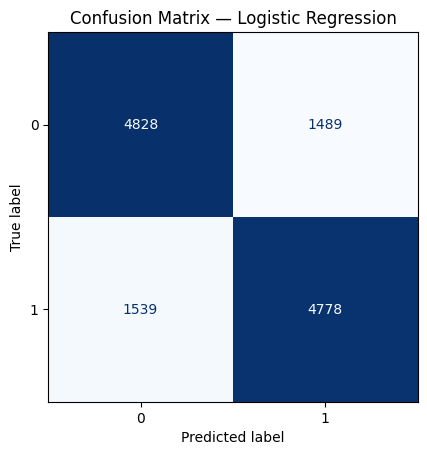

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_val_scaled,
    y_train_resampled,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix — Logistic Regression")
plt.show()


2. Tree-based Models:

 Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)


In [54]:
dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [55]:
y_val_pred_dt = dt_model.predict(X_train_resampled)


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_train_resampled, y_val_pred_dt))


              precision    recall  f1-score   support

           0       0.76      0.72      0.74      6317
           1       0.73      0.77      0.75      6317

    accuracy                           0.74     12634
   macro avg       0.75      0.74      0.74     12634
weighted avg       0.75      0.74      0.74     12634



In [57]:
from sklearn.metrics import roc_auc_score

y_prob_dt = dt_model.predict_proba(X_train_resampled)[:,1]
print("ROC-AUC:", roc_auc_score(y_train_resampled, y_prob_dt))


ROC-AUC: 0.8308707574228051


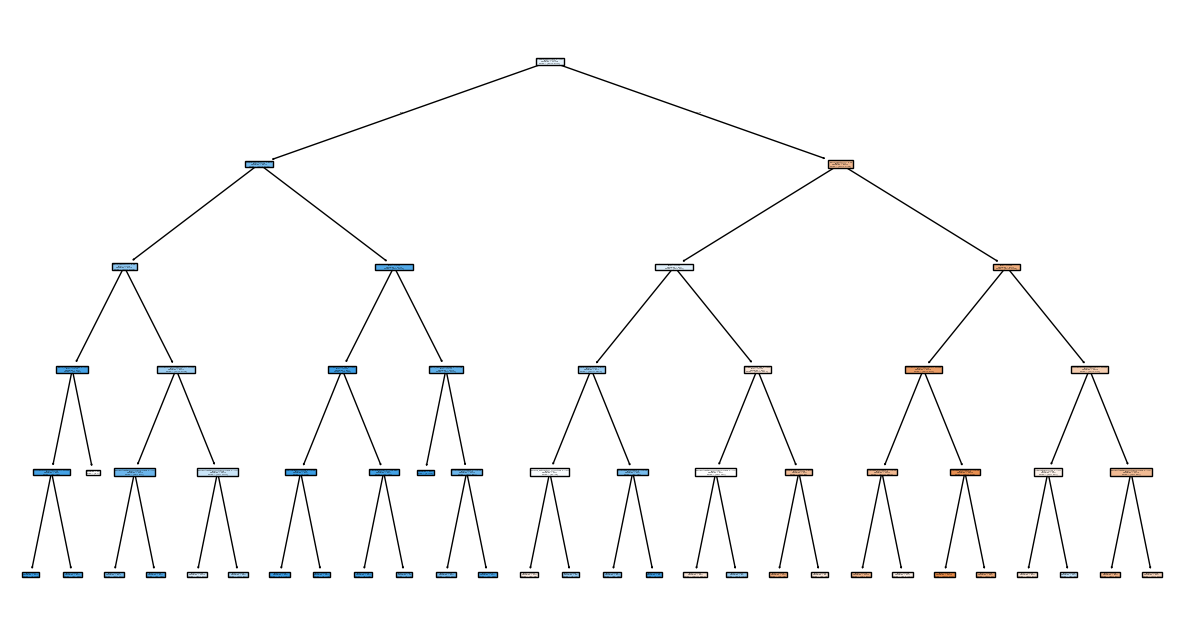

In [58]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(dt_model, filled=True, feature_names=X_train.columns)
plt.show()


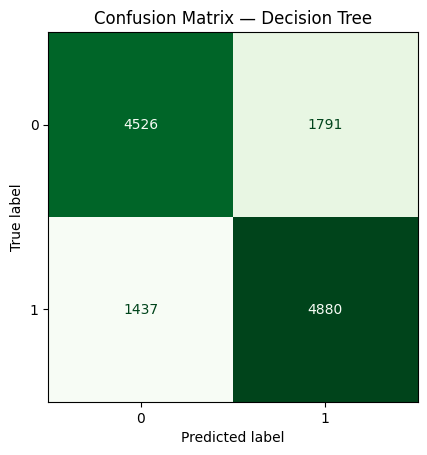

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_train_resampled,
    y_train_resampled,
    cmap="Greens",
    colorbar=False
)

plt.title("Confusion Matrix — Decision Tree")
plt.show()


Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [61]:
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [62]:
y_val_pred_rf = rf_model.predict(X_train_resampled)


In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_train_resampled, y_val_pred_rf))


              precision    recall  f1-score   support

           0       0.77      0.75      0.76      6317
           1       0.76      0.78      0.77      6317

    accuracy                           0.76     12634
   macro avg       0.76      0.76      0.76     12634
weighted avg       0.76      0.76      0.76     12634



In [64]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_train_resampled)[:,1]
print("ROC-AUC:", roc_auc_score(y_train_resampled, y_prob_rf))


ROC-AUC: 0.862927351356385


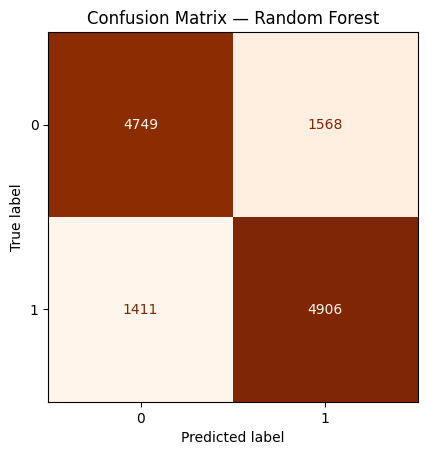

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_train_resampled,
    y_train_resampled,
    cmap="Oranges",
    colorbar=False
)

plt.title("Confusion Matrix — Random Forest")
plt.show()


Gradient Boosting

In [66]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)


In [67]:
gb_model.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t`

In [68]:
y_val_pred_gb = gb_model.predict(X_train_resampled)


In [69]:
from sklearn.metrics import classification_report
print(classification_report(y_train_resampled, y_val_pred_gb))


              precision    recall  f1-score   support

           0       0.81      0.76      0.79      6317
           1       0.78      0.82      0.80      6317

    accuracy                           0.79     12634
   macro avg       0.79      0.79      0.79     12634
weighted avg       0.79      0.79      0.79     12634



In [70]:
from sklearn.metrics import roc_auc_score

y_prob_gb = gb_model.predict_proba(X_train_resampled)[:,1]
print("ROC-AUC:", roc_auc_score(y_train_resampled, y_prob_gb))


ROC-AUC: 0.8787159509798509


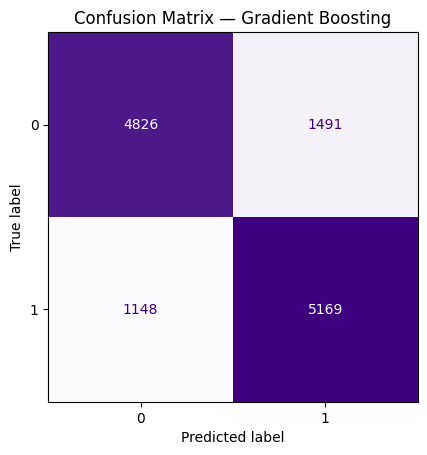

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    gb_model,
    X_train_resampled,
    y_train_resampled,
    cmap="Purples",
    colorbar=False
)

plt.title("Confusion Matrix — Gradient Boosting")
plt.show()


XGBoost

In [72]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)


In [73]:
xgb_model.fit(X_train, y_train)


C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:05:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [74]:
y_val_pred_xgb = xgb_model.predict(X_train_resampled)


In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_train_resampled, y_val_pred_xgb))


              precision    recall  f1-score   support

           0       0.84      0.85      0.84      6317
           1       0.84      0.84      0.84      6317

    accuracy                           0.84     12634
   macro avg       0.84      0.84      0.84     12634
weighted avg       0.84      0.84      0.84     12634



In [76]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb_model.predict_proba(X_train_resampled)[:,1]
print("ROC-AUC:", roc_auc_score(y_train_resampled, y_prob_xgb))


ROC-AUC: 0.9241264560485913


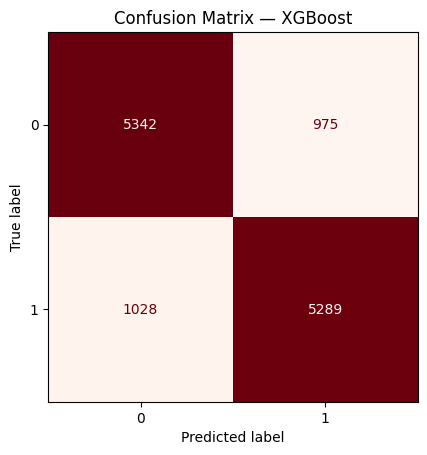

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_train_resampled,
    y_train_resampled,
    cmap="Reds",
    colorbar=False
)

plt.title("Confusion Matrix — XGBoost")
plt.show()


3. Other Models:

Support Vector Machine (SVM)

In [78]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42
)


In [79]:
svm_model.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [80]:
y_val_pred_svm = svm_model.predict(X_val_scaled)


In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_train_resampled, y_val_pred_svm))


              precision    recall  f1-score   support

           0       0.78      0.76      0.77      6317
           1       0.76      0.78      0.77      6317

    accuracy                           0.77     12634
   macro avg       0.77      0.77      0.77     12634
weighted avg       0.77      0.77      0.77     12634



In [82]:
from sklearn.metrics import roc_auc_score

y_prob_svm = svm_model.predict_proba(X_val_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_train_resampled, y_prob_svm))


ROC-AUC: 0.8933981838484387


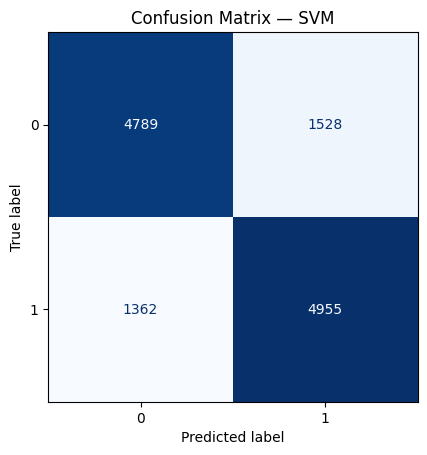

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_val_scaled,
    y_train_resampled,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix — SVM")
plt.show()


 K-Nearest Neighbors

In [84]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski"
)


In [86]:
knn_model.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [16]:
y_val_pred_knn = knn_model.predict(X_val_scaled)


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_train_resampled, y_val_pred_knn))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6317
           1       0.98      1.00      0.99      6317

    accuracy                           0.99     12634
   macro avg       0.99      0.99      0.99     12634
weighted avg       0.99      0.99      0.99     12634



In [87]:
from sklearn.metrics import roc_auc_score

y_prob_knn = knn_model.predict_proba(X_val_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_train_resampled, y_prob_knn))


ROC-AUC: 1.0


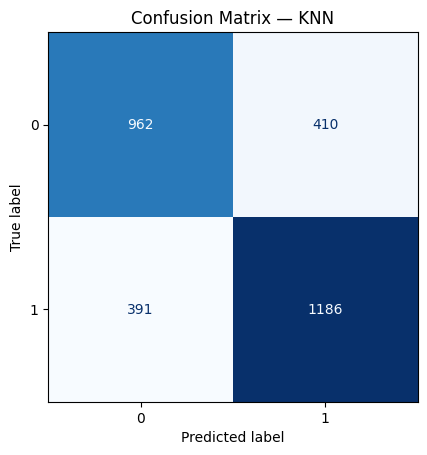

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test_scaled,
    y_test,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix — KNN")
plt.show()


Naive Bayes

In [89]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()


In [90]:
nb_model.fit(X_train_scaled, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [91]:
y_val_pred_nb = nb_model.predict(X_val_scaled)


In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_train_resampled, y_val_pred_nb))


              precision    recall  f1-score   support

           0       0.77      0.73      0.75      6317
           1       0.74      0.78      0.76      6317

    accuracy                           0.75     12634
   macro avg       0.75      0.75      0.75     12634
weighted avg       0.75      0.75      0.75     12634



In [93]:
from sklearn.metrics import roc_auc_score

y_prob_nb = nb_model.predict_proba(X_val_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_train_resampled, y_prob_nb))


ROC-AUC: 0.7952832198903736


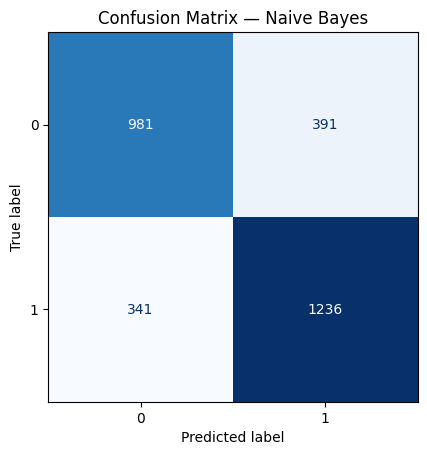

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test_scaled,
    y_test,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix — Naive Bayes")
plt.show()


TASK 7: MODEL EVALUATION

In [95]:
import pandas as pd
from sklearn.metrics import roc_auc_score

auc_scores = {
    "Logistic Regression": roc_auc_score(y_train_resampled, lr_model.predict_proba(X_val_scaled)[:,1]),
    "Decision Tree": roc_auc_score(y_train_resampled, dt_model.predict_proba(X_val_scaled)[:,1]),
    "Random Forest": roc_auc_score(y_train_resampled, rf_model.predict_proba(X_val_scaled)[:,1]),
    "Gradient Boosting": roc_auc_score(y_train_resampled, gb_model.predict_proba(X_val_scaled)[:,1]),
    "XGBoost": roc_auc_score(y_train_resampled, xgb_model.predict_proba(X_val_scaled)[:,1]),
    "SVM": roc_auc_score(y_train_resampled, svm_model.predict_proba(X_val_scaled)[:,1]),
    "KNN": roc_auc_score(y_train_resampled, knn_model.predict_proba(X_val_scaled)[:,1]),
    "Naive Bayes": roc_auc_score(y_train_resampled, nb_model.predict_proba(X_val_scaled)[:,1])
}

auc_table = pd.DataFrame(auc_scores.items(), columns=["Model","AUC Score"])
auc_table = auc_table.sort_values("AUC Score", ascending=False)

print(auc_table)


C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


                 Model  AUC Score
6                  KNN   1.000000
5                  SVM   0.893398
0  Logistic Regression   0.843557
2        Random Forest   0.816821
7          Naive Bayes   0.795283
1        Decision Tree   0.789026
3    Gradient Boosting   0.757312
4              XGBoost   0.672702


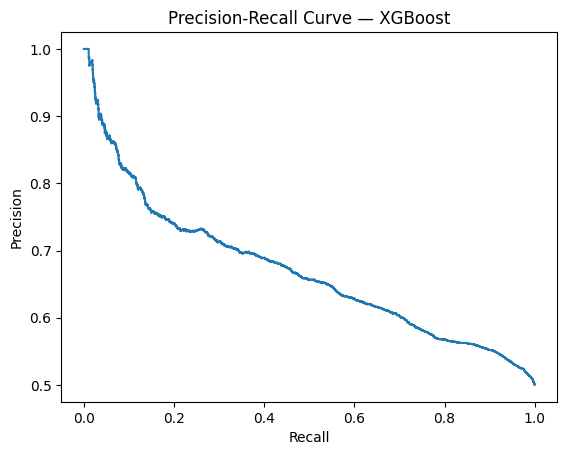

PR AUC: 0.6697468238226628


In [96]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


y_prob = xgb_model.predict_proba(X_val_scaled)[:,1]


precision, recall, thresholds = precision_recall_curve(y_train_resampled, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost")
plt.show()


print("PR AUC:", average_precision_score(y_train_resampled, y_prob))


C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


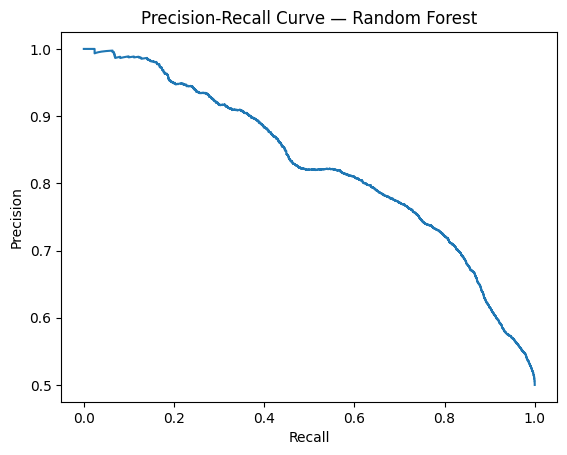

PR AUC: 0.8260515581848475


In [97]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


y_prob = rf_model.predict_proba(X_val_scaled)[:,1]


precision, recall, thresholds = precision_recall_curve(y_train_resampled, y_prob)

# plot curve
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest")
plt.show()


print("PR AUC:", average_precision_score(y_train_resampled, y_prob))


for Random Forest

In [98]:
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feat_imp = feat_imp.sort_values("Importance", ascending=False)
print(feat_imp.head(20))


                                      Feature  Importance
11                         IsLongTermContract    0.292372
17                          Contract_One year    0.104484
18                          Contract_Two year    0.073270
1                               Tenure_Months    0.053932
4                   CustomerSatisfactionScore    0.045826
6                              ChargePerMonth    0.044827
2                              MonthlyCharges    0.041832
15                      Tenure_MonthlyCharges    0.028913
5                                TotalCharges    0.028364
8            Service_Satisfaction_Interaction    0.023953
42        Contract_TenureGroup_One year_49-72    0.023614
41        Contract_TenureGroup_One year_25-48    0.022685
38  Contract_TenureGroup_Month-to-month_49-72    0.019390
45        Contract_TenureGroup_Two year_25-48    0.016506
37  Contract_TenureGroup_Month-to-month_25-48    0.016487
9                         AvgChargePerService    0.015591
46        Cont

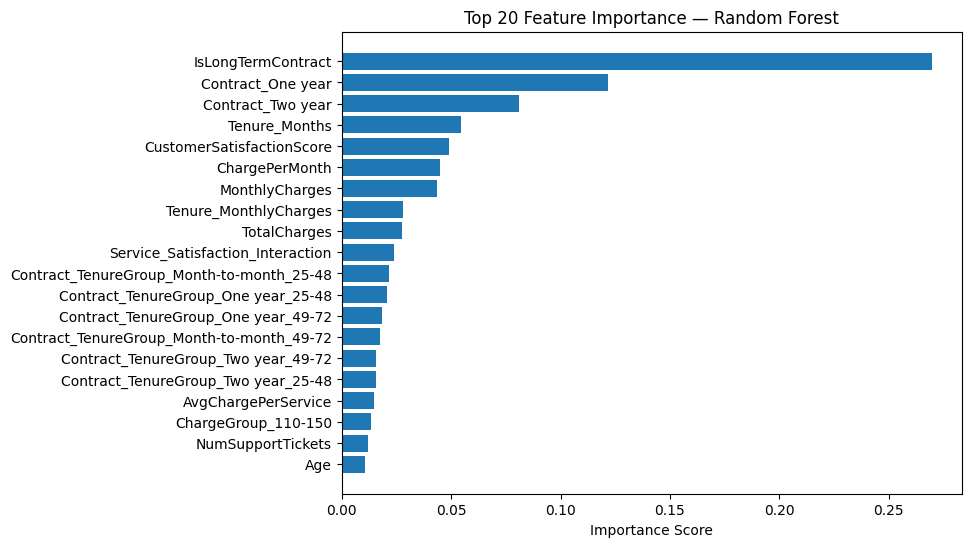

In [123]:
import matplotlib.pyplot as plt

top20 = feat_imp.head(20)

plt.figure(figsize=(8,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.show()


for Decision Tree

In [99]:
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

feat_imp = feat_imp.sort_values("Importance", ascending=False)
print(feat_imp.head(20))

                             Feature  Importance
11                IsLongTermContract    0.658802
4          CustomerSatisfactionScore    0.100380
1                      Tenure_Months    0.099063
2                     MonthlyCharges    0.095544
3                  NumSupportTickets    0.016729
21    PaymentMethod_Electronic check    0.012395
15             Tenure_MonthlyCharges    0.009267
25                OnlineSecurity_Yes    0.003792
24                InternetService_No    0.002646
8   Service_Satisfaction_Interaction    0.001034
6                     ChargePerMonth    0.000282
9                AvgChargePerService    0.000066
7                       ServiceCount    0.000000
10               ServiceAdoptionRate    0.000000
13                       IsHighValue    0.000000
5                       TotalCharges    0.000000
12               HasMultipleServices    0.000000
0                                Age    0.000000
17                 Contract_One year    0.000000
16                  

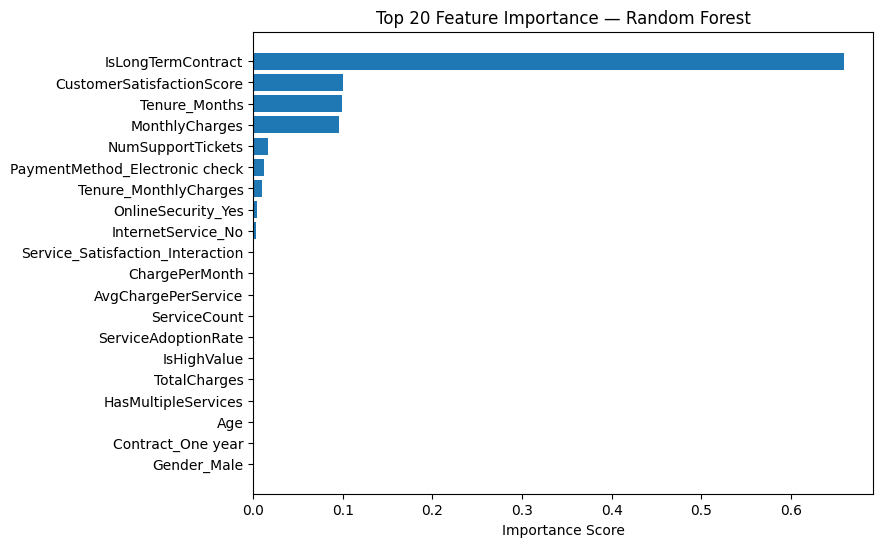

In [100]:
import matplotlib.pyplot as plt

top20 = feat_imp.head(20)

plt.figure(figsize=(8,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.show()

for Gradient Boosting

In [127]:
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

feat_imp = feat_imp.sort_values("Importance", ascending=False)
print(feat_imp.head(20))

                                Feature  Importance
10                   IsLongTermContract    0.521475
1                         Tenure_Months    0.092920
2                        MonthlyCharges    0.088627
4             CustomerSatisfactionScore    0.087421
6                        ChargePerMonth    0.029744
11                  AvgChargePerService    0.027020
3                     NumSupportTickets    0.025476
13                Tenure_MonthlyCharges    0.021068
0                                   Age    0.019788
20       PaymentMethod_Electronic check    0.015577
5                          TotalCharges    0.014498
24                   OnlineSecurity_Yes    0.011506
12     Service_Satisfaction_Interaction    0.009628
27                      TechSupport_Yes    0.002522
28                      StreamingTV_Yes    0.002422
7                          ServiceCount    0.002109
44  Contract_TenureGroup_Two year_25-48    0.001949
18                 PaperlessBilling_Yes    0.001766
26          

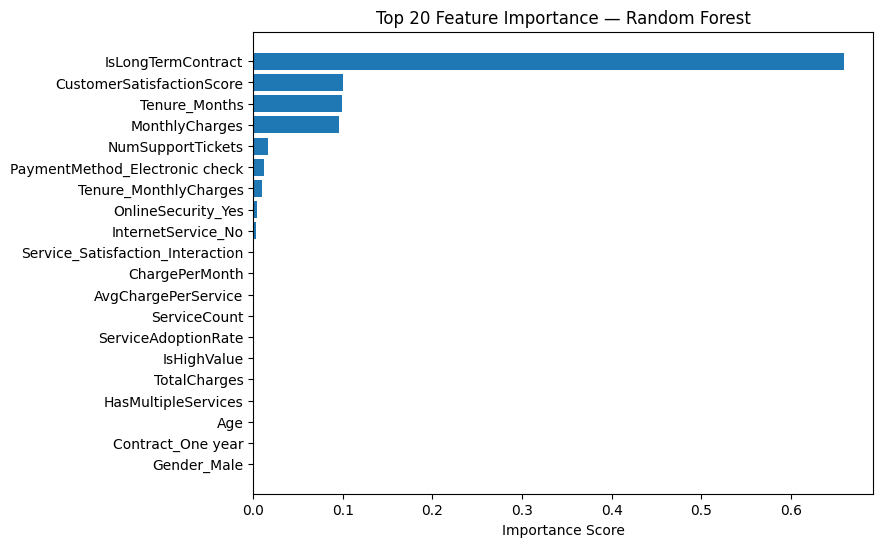

In [101]:
import matplotlib.pyplot as plt

top20 = feat_imp.head(20)

plt.figure(figsize=(8,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.show()

for XGBoost

In [102]:
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feat_imp = feat_imp.sort_values("Importance", ascending=False)
print(feat_imp.head(20))

                                Feature  Importance
11                   IsLongTermContract    0.269432
18                    Contract_Two year    0.146098
17                    Contract_One year    0.085965
49                  ChargeGroup_110-150    0.034584
4             CustomerSatisfactionScore    0.028751
14                             IsAtRisk    0.018195
1                         Tenure_Months    0.017713
39   Contract_TenureGroup_One year_0-12    0.015390
21       PaymentMethod_Electronic check    0.015257
43   Contract_TenureGroup_Two year_0-12    0.015123
6                        ChargePerMonth    0.014312
2                        MonthlyCharges    0.014068
25                   OnlineSecurity_Yes    0.012316
3                     NumSupportTickets    0.011381
15                Tenure_MonthlyCharges    0.010710
12                  HasMultipleServices    0.010417
5                          TotalCharges    0.009610
33                    TenureGroup_13-24    0.009408
44  Contract

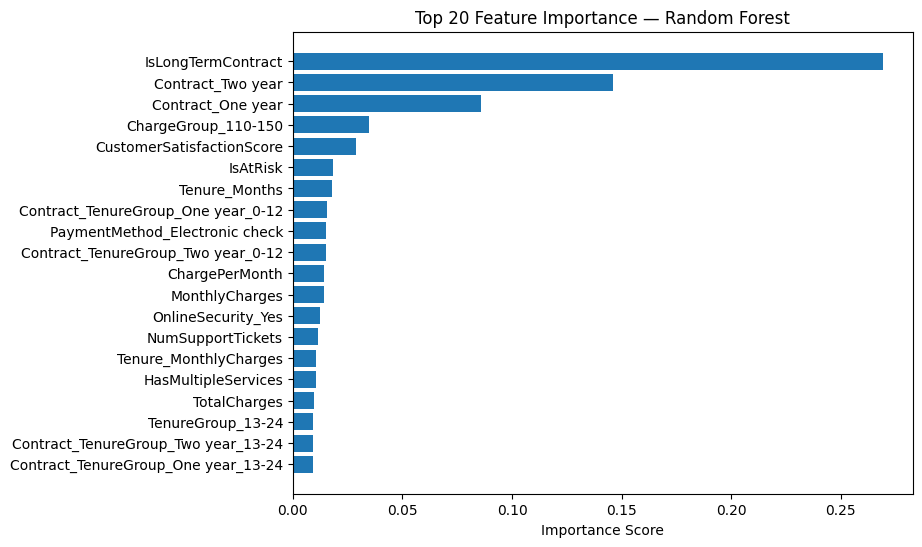

In [103]:
import matplotlib.pyplot as plt

top20 = feat_imp.head(20)

plt.figure(figsize=(8,6))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [104]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("Score")
    plt.legend()
    plt.grid()
    plt.show()


Logistic Regression

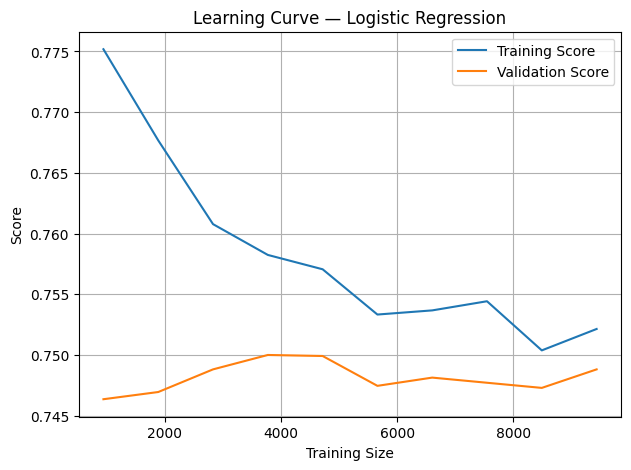

In [105]:
plot_learning_curve(lr_model, X_train_scaled, y_train, "Learning Curve — Logistic Regression")


Random Forest

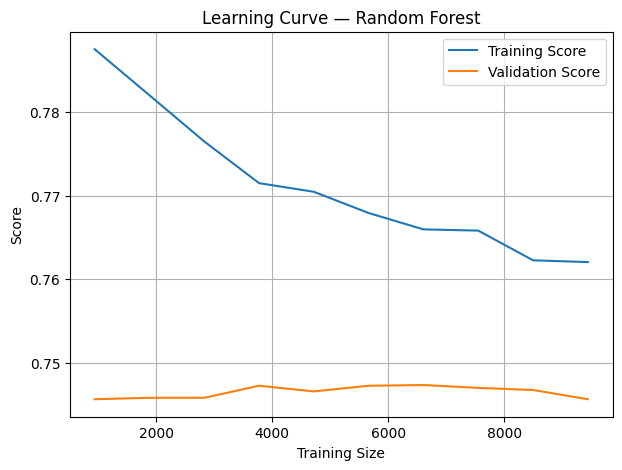

In [133]:
plot_learning_curve(rf_model, X_train, y_train, "Learning Curve — Random Forest")


XGBoost

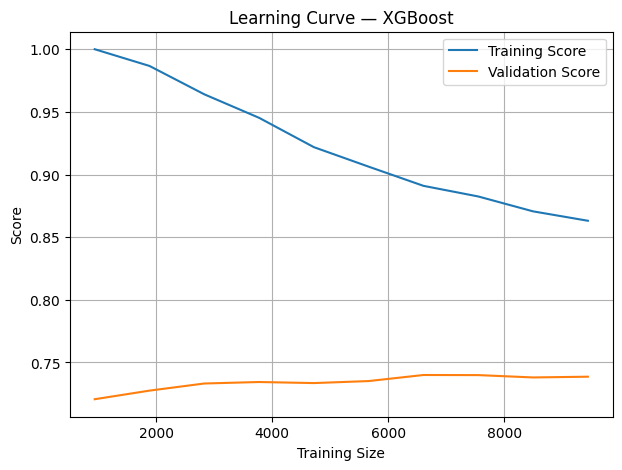

In [106]:
plot_learning_curve(xgb_model, X_train, y_train, "Learning Curve — XGBoost")


SVM

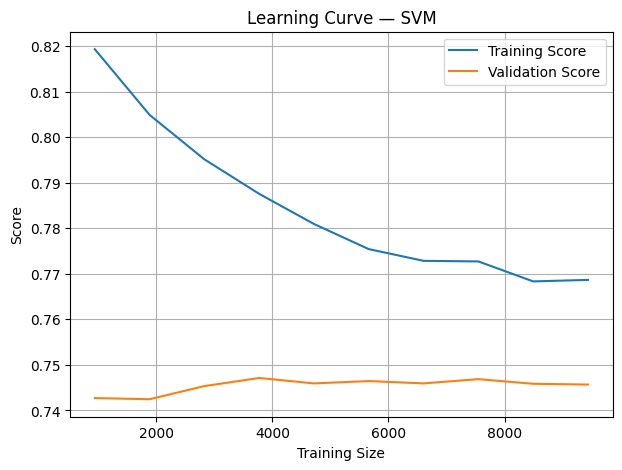

In [109]:
plot_learning_curve(svm_model, X_train_scaled, y_train, "Learning Curve — SVM")


Cross-Validation

Random Fores

In [110]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy","precision","recall","f1","roc_auc"]
)

for metric in scores:
    print(metric, scores[metric].mean(), "+/-", scores[metric].std())


fit_time 0.4516292572021484 +/- 0.007733034223691378
score_time 0.10598363876342773 +/- 0.0006798413972704585
test_accuracy 0.7465240226755089 +/- 0.0030980747573491735
test_precision 0.7637079240368045 +/- 0.007044939076938791
test_recall 0.7628616815498563 +/- 0.007209149671240933
test_f1 0.7632234456951154 +/- 0.0020604116376315793
test_roc_auc 0.8315212944185477 +/- 0.005123432263924118


Logistic Regression

In [111]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring=["accuracy","precision","recall","f1","roc_auc"]
)

for metric in scores:
    print(metric, scores[metric].mean(), "+/-", scores[metric].std())


fit_time 0.024117088317871092 +/- 0.0016025443270870391
score_time 0.007687520980834961 +/- 0.00018651693749632974
test_accuracy 0.7486430259877426 +/- 0.009482428161859827
test_precision 0.7720785608244195 +/- 0.010750791840852965
test_recall 0.7530455415576736 +/- 0.00996771895137012
test_f1 0.762402229539238 +/- 0.008713246878559967
test_roc_auc 0.8304422339635231 +/- 0.009173647886394142


Decision Tree

In [112]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy","precision","recall","f1","roc_auc"]
)


for metric in scores:
    print(metric, scores[metric].mean(), "+/-", scores[metric].std())

fit_time 0.03861641883850098 +/- 0.0006807281744364639
score_time 0.009533500671386719 +/- 0.0003006206467116308
test_accuracy 0.747880278198892 +/- 0.006006073877147522
test_precision 0.7610803356091973 +/- 0.012376674072674718
test_recall 0.7720430309590387 +/- 0.010577187672280974
test_f1 0.7663599304170204 +/- 0.0031380804540035025
test_roc_auc 0.8282148850779167 +/- 0.005557595932167918


Gradient Boosting

In [113]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    gb_model,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy","precision","recall","f1","roc_auc"]
)



for metric in scores:
    print(metric, scores[metric].mean(), "+/-", scores[metric].std())

fit_time 7.948345184326172 +/- 0.03517105979352274
score_time 0.021063566207885742 +/- 0.00013581608057766143
test_accuracy 0.7425397144725214 +/- 0.008072073160725836
test_precision 0.7576766206561694 +/- 0.011754638772404093
test_recall 0.7638121761528207 +/- 0.006529030798367393
test_f1 0.7606546306998813 +/- 0.005786989868175688
test_roc_auc 0.8296850748498269 +/- 0.005370064474271173


XGBoost

In [114]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring=["accuracy","precision","recall","f1","roc_auc"]
)


for metric in scores:
    print(metric, scores[metric].mean(), "+/-", scores[metric].std())

C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:13:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:13:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:13:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarni

fit_time 0.315062952041626 +/- 0.005860540584445131
score_time 0.023029518127441407 +/- 0.0004740054785397348
test_accuracy 0.7366057867093928 +/- 0.005979411282502707
test_precision 0.7667510889001312 +/- 0.010769027050643318
test_recall 0.730727647654269 +/- 0.008630052124895655
test_f1 0.7482065523047823 +/- 0.004453184595625586
test_roc_auc 0.8252404809217406 +/- 0.006407864289710845


SVM

In [115]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring=["accuracy","precision","recall","f1","roc_auc"]
)

for metric in scores:
    print(metric, scores[metric].mean(), "+/-", scores[metric].std())

fit_time 13.374242544174194 +/- 0.13088043315011644
score_time 1.773004150390625 +/- 0.008954610149005662
test_accuracy 0.7456761698795094 +/- 0.005117042947706357
test_precision 0.7610158218126492 +/- 0.009942526420617706
test_recall 0.7658707668099863 +/- 0.005959807887117836
test_f1 0.7633541581493627 +/- 0.002441817166080013
test_roc_auc 0.8111173842141153 +/- 0.005282567715676675


KNN

In [116]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring=["accuracy","precision","recall","f1","roc_auc"]
)

for metric in scores:
    print(metric, scores[metric].mean(), "+/-", scores[metric].std())

fit_time 0.0031084537506103514 +/- 0.0005149942723794466
score_time 0.06519269943237305 +/- 0.006397464412779783
test_accuracy 0.7213461607547007 +/- 0.0072140201976698595
test_precision 0.7442069556292855 +/- 0.009130506136697527
test_recall 0.7310437275123525 +/- 0.0048356963871291365
test_f1 0.7375416971458002 +/- 0.005845422669440846
test_roc_auc 0.7848548794983132 +/- 0.007873764838774437


Final Model Selection

XGBoost

In [117]:
final_model = xgb_model
final_model.fit(X_train_resampled, y_train_resampled)



C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:15:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [118]:

from sklearn.metrics import classification_report, roc_auc_score

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))


              precision    recall  f1-score   support

           0       0.70      0.75      0.73      1372
           1       0.77      0.73      0.75      1577

    accuracy                           0.74      2949
   macro avg       0.74      0.74      0.74      2949
weighted avg       0.74      0.74      0.74      2949

Test ROC-AUC: 0.8285972646146964


TASK 8: MODEL INTERPRETATION

In [119]:
import shap
explainer = shap.TreeExplainer(xgb_model)


C:\Users\PIJUSH PANDIT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [120]:
shap_values = explainer.shap_values(X_test)


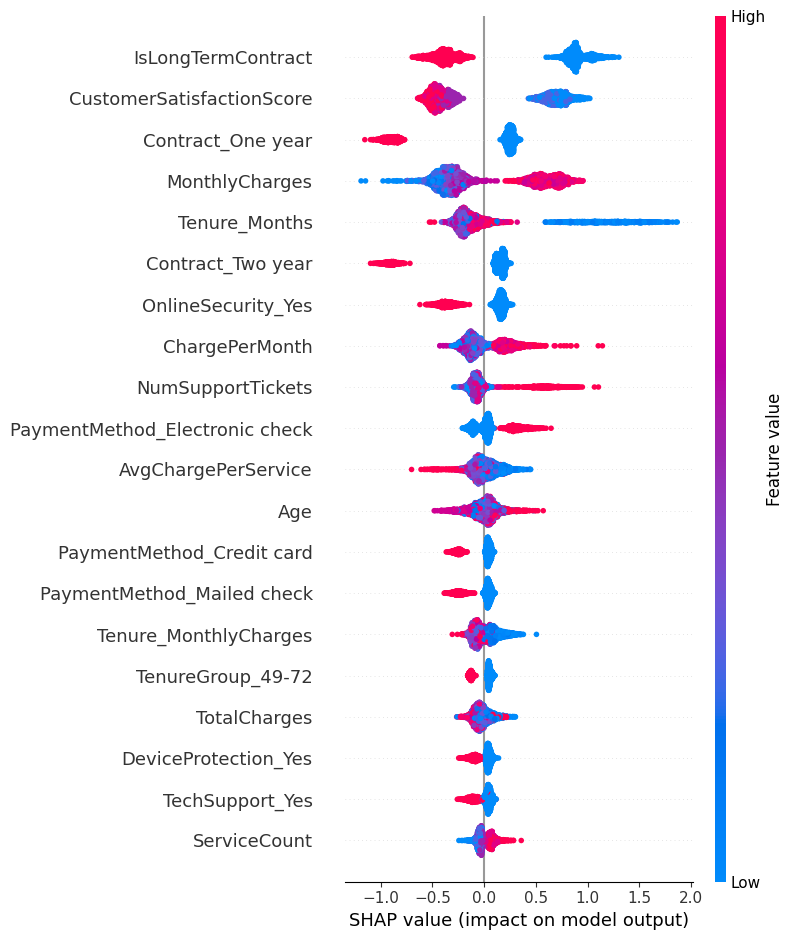

In [121]:
shap.summary_plot(shap_values, X_test)


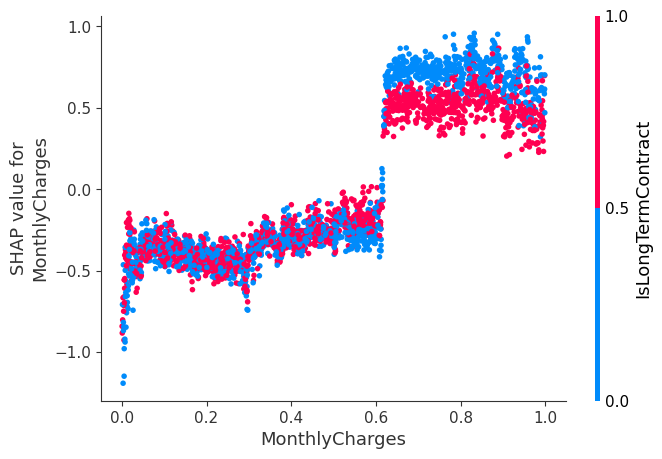

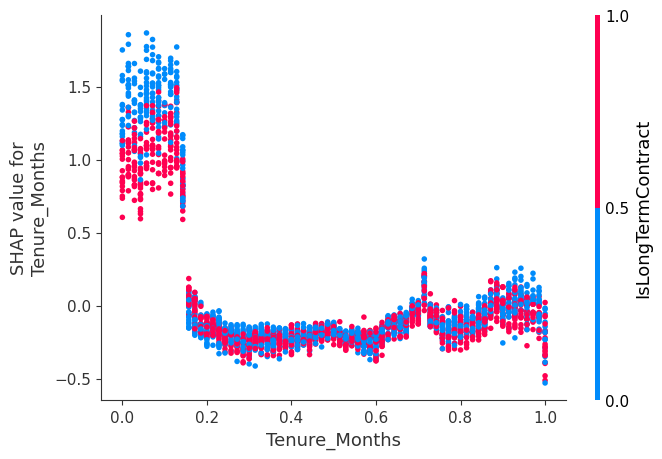

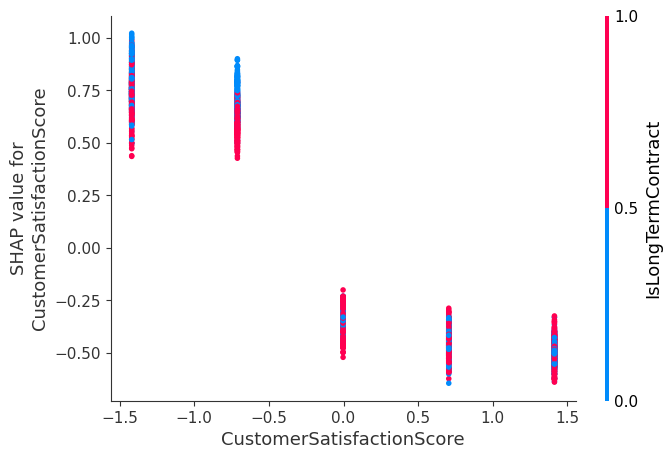

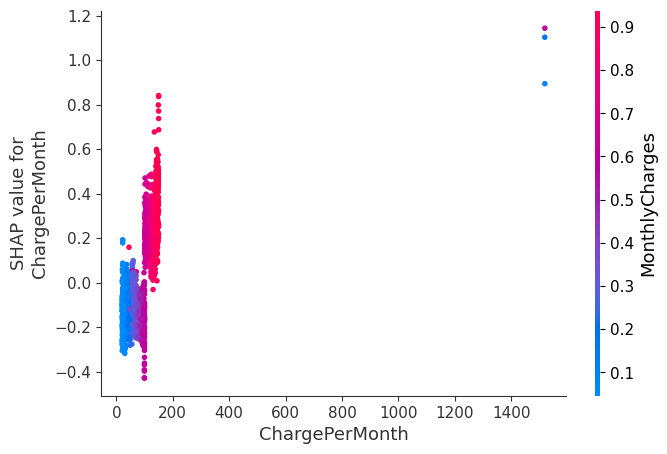

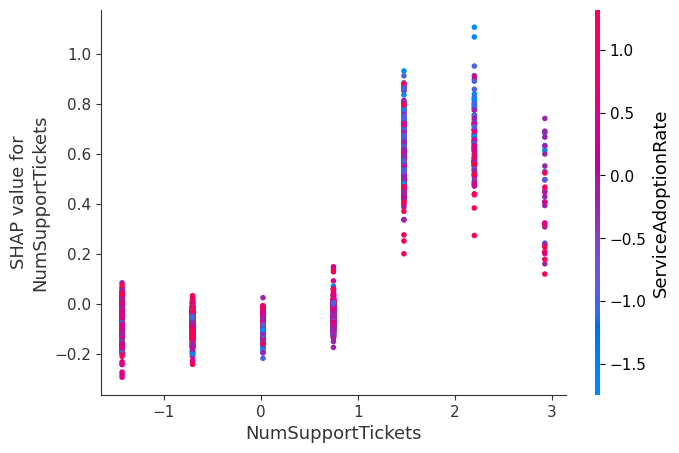

In [122]:

shap.dependence_plot("MonthlyCharges", shap_values, X_test)
shap.dependence_plot("Tenure_Months", shap_values, X_test)
shap.dependence_plot("CustomerSatisfactionScore", shap_values, X_test)
shap.dependence_plot("ChargePerMonth", shap_values, X_test)
shap.dependence_plot("NumSupportTickets", shap_values, X_test)

In [123]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [124]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

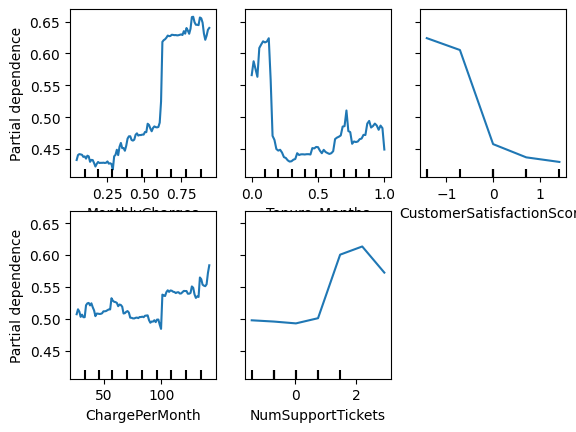

In [125]:
features = ["MonthlyCharges", "Tenure_Months", "CustomerSatisfactionScore", "ChargePerMonth", "NumSupportTickets"]

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_test,
    features
)

plt.show()

TASK 9: CUSTOMER SEGMENTATION

In [126]:
from sklearn.preprocessing import StandardScaler

X_cluster = df1.select_dtypes(include=["int64","float64"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

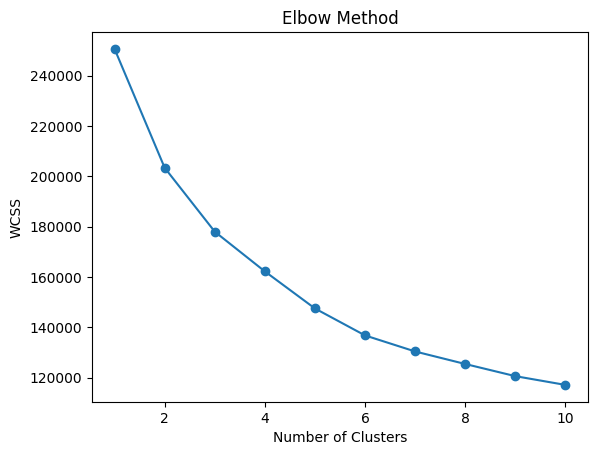

In [127]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [128]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df1["Cluster"] = clusters

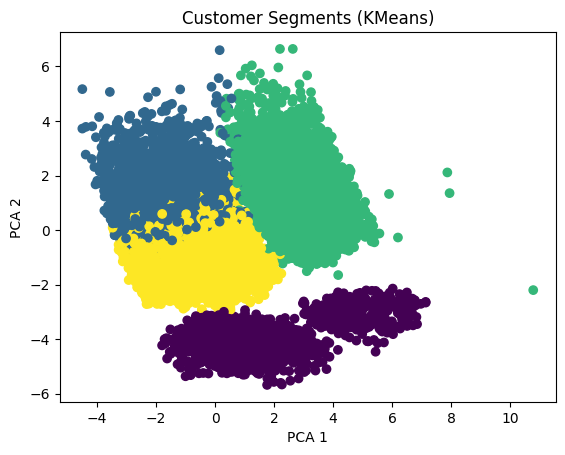

In [129]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.scatter(components[:,0], components[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (KMeans)")
plt.show()

In [130]:
cluster_summary = df1.groupby("Cluster").mean(numeric_only=True)
print(cluster_summary)

              Age  Tenure_Months  MonthlyCharges  NumSupportTickets  \
Cluster                                                               
0       -0.015061       0.508211        0.491837           0.007763   
1        0.039924       0.438044        0.366442          -0.063116   
2       -0.013019       0.762020        0.734404          -0.026553   
3       -0.016649       0.376696        0.444156           0.055396   

         CustomerSatisfactionScore  TotalCharges     Churn  ChargePerMonth  \
Cluster                                                                      
0                        -0.012959      0.331219  0.524633       83.851971   
1                         0.619620      0.205890  0.385819       67.697083   
2                         0.006885      0.669973  0.559763      117.795092   
3                        -0.415581      0.200926  0.623897       77.918995   

         ServiceCount  Service_Satisfaction_Interaction  AvgChargePerService  \
Cluster                 

In [131]:
segment_size = df1["Cluster"].value_counts().sort_index()
print(segment_size)

Cluster
0    1157
1    4090
2    3380
3    6118
Name: count, dtype: int64


In [132]:
churn_rate = df1.groupby("Cluster")["Churn"].mean()
print((churn_rate*100).round(2))

Cluster
0    52.46
1    38.58
2    55.98
3    62.39
Name: Churn, dtype: float64


In [133]:
segment_profile = df1.groupby("Cluster").mean(numeric_only=True)
print(segment_profile)

              Age  Tenure_Months  MonthlyCharges  NumSupportTickets  \
Cluster                                                               
0       -0.015061       0.508211        0.491837           0.007763   
1        0.039924       0.438044        0.366442          -0.063116   
2       -0.013019       0.762020        0.734404          -0.026553   
3       -0.016649       0.376696        0.444156           0.055396   

         CustomerSatisfactionScore  TotalCharges     Churn  ChargePerMonth  \
Cluster                                                                      
0                        -0.012959      0.331219  0.524633       83.851971   
1                         0.619620      0.205890  0.385819       67.697083   
2                         0.006885      0.669973  0.559763      117.795092   
3                        -0.415581      0.200926  0.623897       77.918995   

         ServiceCount  Service_Satisfaction_Interaction  AvgChargePerService  \
Cluster                 

In [134]:
revenue = df1.groupby("Cluster")["TotalCharges"].mean()
print(revenue)

Cluster
0    0.331219
1    0.205890
2    0.669973
3    0.200926
Name: TotalCharges, dtype: float64


TASK 10: DEPLOYMENT PREPARATION

In [136]:
import joblib

joblib.dump(final_model, "Final_Model.pkl")

['Final_Model.pkl']

In [137]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [211]:
features = model.feature_names_in_.tolist()

In [202]:
import joblib

correct_features = model.feature_names_in_.tolist()

joblib.dump(correct_features, "feature_names.pkl")

print("Total features:", len(correct_features))
print(correct_features[:15])

Total features: 50
['Age', 'Tenure_Months', 'MonthlyCharges', 'NumSupportTickets', 'CustomerSatisfactionScore', 'TotalCharges', 'ChargePerMonth', 'ServiceCount', 'Service_Satisfaction_Interaction', 'AvgChargePerService', 'ServiceAdoptionRate', 'IsLongTermContract', 'HasMultipleServices', 'IsHighValue', 'IsAtRisk']


In [212]:
def preprocess_input(input_dict):

    # create empty dataframe with correct columns
    df = pd.DataFrame(0, index=[0], columns=features)

    for key, value in input_dict.items():

        # numeric columns
        if key in df.columns:
            df.at[0, key] = value

        # categorical one-hot columns
        col_name = f"{key}_{value}"
        if col_name in df.columns:
            df.at[0, col_name] = 1

    # engineered features
    if "MonthlyCharges" in input_dict:
        df["ChargePerMonth"] = input_dict["MonthlyCharges"]

    if "MonthlyCharges" in input_dict and "ServiceCount" in input_dict:
        df["AvgChargePerService"] = (
            input_dict["MonthlyCharges"] /
            max(1, input_dict["ServiceCount"])
        )

    if "Contract" in input_dict:
        df["IsLongTermContract"] = int(
            input_dict["Contract"] in ["One year", "Two year"]
        )

    if "CustomerSatisfactionScore" in input_dict and "NumSupportTickets" in input_dict:
        df["IsAtRisk"] = int(
            input_dict["CustomerSatisfactionScore"] <= 2
            and input_dict["NumSupportTickets"] >= 3
        )

    return df

In [204]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load("Final_Model.pkl")
scaler = joblib.load("scaler.pkl")
features = joblib.load("feature_names.pkl")

In [205]:
def preprocess_input(input_dict):
    df = pd.DataFrame(np.zeros((1, len(features))), columns=features)

    for key, value in input_dict.items():

        # numeric features
        if key in df.columns:
            df[key] = value

        # categorical encoded features
        else:
            col_name = f"{key}_{value}"
            if col_name in df.columns:
                df[col_name] = 1

    return df

In [206]:
def predict_churn(input_dict):
    df = preprocess_input(input_dict)
    df_scaled = scaler.transform(df)
    return model.predict(df_scaled)[0]


def predict_probability(input_dict):
    df = preprocess_input(input_dict)
    df_scaled = scaler.transform(df)
    return model.predict_proba(df_scaled)[0][1]

In [214]:
customer = {
    "Age":35,
    "Tenure_Months":10,
    "MonthlyCharges":90,
    "ServiceCount":2,
    "CustomerSatisfactionScore":3,
    "NumSupportTickets":1,
    "Contract":"One year"
}

print("Prediction:", predict_churn(customer))
print("Probability:", predict_probability(customer))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- ChargeGroup_110-150
- ChargeGroup_50-80
- ChargeGroup_80-110
- Contract_One year
- Contract_TenureGroup_Month-to-month_13-24
- ...
Feature names seen at fit time, yet now missing:
- Churn


In [197]:
features = joblib.load("feature_names.pkl")
print(features[:10])

['Age', 'Tenure_Months', 'MonthlyCharges', 'NumSupportTickets', 'CustomerSatisfactionScore', 'TotalCharges', 'ChargePerMonth', 'ServiceCount', 'Service_Satisfaction_Interaction', 'AvgChargePerService']


In [201]:
features = joblib.load("feature_names.pkl")
print(features[:15])

['Age', 'Tenure_Months', 'MonthlyCharges', 'NumSupportTickets', 'CustomerSatisfactionScore', 'TotalCharges', 'ChargePerMonth', 'ServiceCount', 'Service_Satisfaction_Interaction', 'AvgChargePerService', 'ServiceAdoptionRate', 'IsLongTermContract', 'HasMultipleServices', 'IsHighValue', 'IsAtRisk']
